In [4]:
#importing libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as matplot
import re
import logging
import os
import warnings
import altair as alt
warnings.filterwarnings("ignore")


In [14]:
#reading excel with multiple sheets and selecting a specific sheet
xls = pd.ExcelFile('csv_data/data2.xlsx')

In [16]:
xls.sheet_names

['QUESTIONNAIRE',
 'QuestNumericValues',
 'RetrospectiveNumeric',
 'Week 1 ',
 'Week 2',
 'Week 3',
 'Week 4',
 'Week 5',
 'Week 6',
 'Week 7',
 'Week8',
 'Week 9',
 'Week 10',
 '11 only 2']

In [18]:
week1_df = pd.read_excel(xls, 'Week 1 ')
week1_df.head

<bound method NDFrame.head of     Mark on Task 1 out of 25 Mark on Task 2 out of 25  \
0                        NaN                      NaN   
1                       0.48                     0.48   
2                                                       
3                                                       
4                       0.28                     0.44   
..                       ...                      ...   
132                       48                       64   
133                       32                       68   
134                      NaN                      NaN   
135                       68                       72   
136                       56                       68   

    Mark on Task 3 out of 25 Mark on Task 4 out of 25  Final mark-task 1  \
0                        NaN                      NaN                NaN   
1                       0.52                                        0.56   
2                                                        

In [8]:
demo_week_2.columns.values[0] = 'student_id'
demo_week_2.columns.values[8] = 'previous_experiences_of_team_working_in_study_and_work'
demo_week_2.columns.values[9] = 'enjoy_working_in_the_team'
demo_week_2.columns.values[10] = 'team_communication_will_be_highly_effective'
demo_week_2.columns.values[11] = 'team_communication_will_be_very_frequent'
demo_week_2.columns.values[12] = 'bond_perosnally_with_my_team_members'
demo_week_2.columns.values[13] = 'we_will_collaborate_together_on_the_same_tasks'
demo_week_2.columns.values[14] = 'work_separately_and_link_up_our_work_later'
demo_week_2.columns.values[15] = 'develop_my_professional_skills'
demo_week_2.columns.values[16] = 'develop_my_team_working_skills'
demo_week_2.columns.values[17] = 'adjust_the_project_regularly'
demo_week_2.columns.values[18] = 'we_will_stick_to_our_original_project'
demo_week_2.columns.values[19] = 'we_will_produce_an_end_result_which_we_are_proud_of'
demo_week_2.columns.values[30] = 'this_module_is_interesting'
demo_week_2.columns.values[31] = 'for_my_own_good'
demo_week_2.columns.values[32] = 'because_i_am_supposed_to_do_it'
demo_week_2.columns.values[33] = 'i_don’t_see_any_good_reasons_in_the_module'
demo_week_2.columns.values[34] = 'this_module_is_pleasant'
demo_week_2.columns.values[35] = 'this_module_is_good_for_me'
demo_week_2.columns.values[36] = 'because_it_is_something_that_i_have_to_do'
demo_week_2.columns.values[37] = 'i_am_not_sure_if_it_is_worth_it'
demo_week_2.columns.values[38] = 'because_this_module_looks_fun'
demo_week_2.columns.values[39] = 'by_personal_decision' 
demo_week_2.columns.values[40] = 'don’t_have_any_choice'
demo_week_2.columns.values[41] = 'don’t_see_what_this_module_brings_me'
demo_week_2.columns.values[42] = 'because_i_feel_good_about_this_module'
demo_week_2.columns.values[43] = 'module_is_important_for_me'
demo_week_2.columns.values[44] = 'i_feel_that_i_have_to_do_it'
demo_week_2.columns.values[45] = 'i_am_not_sure_it_is_a_good_thing_to_pursue_it'

In [109]:
demo_week_2.drop_duplicates().reset_index(drop=True).to_csv('demo_week_2.csv', index=False)
demo = demo_week_2.copy()

In [110]:
[i for i in enumerate(demo_week_2.columns)]

[(0, 'student_id'),
 (1, 'list_of_countries'),
 (2, 'what_is_your_year_of_birth_just_the_year_eg_1995_'),
 (3, 'how_do_you_describe_yourself___selected_choice'),
 (4, 'how_do_you_describe_yourself___prefer_to_self_describe___text'),
 (5, 'what_is_your_first_degree_subject_area'),
 (6, 'how_many_years_work_experience_do_you_have'),
 (7, 'what_sectors_have_you_worked_in'),
 (8, 'enjoy_working_in_the_team'),
 (9, 'team_communication_will_be_highly_effective'),
 (10, 'team_communication_will_be_very_frequent'),
 (11, 'bond_perosnally_with_my_team_members'),
 (12, 'we_will_collaborate_together_on_the_same_tasks'),
 (13, 'work_separately_and_link_up_our_work_later'),
 (14, 'develop_my_professional_skills'),
 (15, 'develop_my_team_working_skills'),
 (16, 'adjust_the_project_regularly'),
 (17, 'we_will_stick_to_our_original_project'),
 (18, 'we_will_stick_to_our_original_project_plan'),
 (19, 'we_will_produce_an_end_result_which_we_are_proud_of'),
 (20, 'i_see_myself_as___extraverted_enthusias

In [111]:
#reading excel with multiple sheets and selecting a specific sheet
demo_numeric = pd.read_excel(xls,'Numeric Demographic',skiprows=1)
demo_numeric.columns = demo_numeric.columns.str.replace(' ','_').str.replace(',','').str.lower().str.replace("-",'_').str.replace("?",'').str.replace("(",'').str.replace(")",'').str.replace('.','').str.replace('&','').str.replace(":",'')
demo_numeric.shape

(212, 46)

In [112]:
demo_numeric.columns.values[0] = 'student_id'
demo_numeric.columns.values[8] = 'previous_experiences_of_team_working_in_study_and_work'
demo_numeric.columns.values[9] = 'i_will_enjoy_working_in_the_team'
demo_numeric.columns.values[10] = 'team_communication_will_be_highly_effective'
demo_numeric.columns.values[11] = 'team_communication_will_be_very_frequent'
demo_numeric.columns.values[12] = 'my_team_will_bond_personally_as_well_as_professionally'
demo_numeric.columns.values[13] = 'we_will_collaborate_together_on_the_same_tasks'
demo_numeric.columns.values[14] = 'work_on_separate_tasks_and_link_them_together_later_on'
demo_numeric.columns.values[15] = 'develop_my_professional_skills_as_a_result_of_the_team_project'
demo_numeric.columns.values[16] = 'develop_my_team_working_skills_and_collaboration'
demo_numeric.columns.values[16] = 'develop_my_team_working_skills_and_collaboration'
demo_numeric.columns.values[17] = 'we_will_adjust_the_project_regularly_as_we_go_along'
demo_numeric.columns.values[18] = 'we_will_stick_to_our_original_project_plan'
demo_numeric.columns.values[19] = 'we_will_produce_an_end_result_which_we_are_proud_of'
demo_numeric.columns.values[30] = 'because_i_think_that_this_module_is_interesting'
demo_numeric.columns.values[31] = 'because_i_am_doing_it_for_my_own_good'
demo_numeric.columns.values[32] = 'because_i_am_supposed_to_do_it'
demo_numeric.columns.values[33] = 'personally_i_don’t_see_any_good_reasons_in_the_module'
demo_numeric.columns.values[34] = 'because_i_think_that_this_module_is_pleasant'
demo_numeric.columns.values[35] = 'because_i_think_that_this_module_is_good_for_me'
demo_numeric.columns.values[36] = 'because_it_is_something_that_i_have_to_do'
demo_numeric.columns.values[37] = 'not_sure_if_it_is_worth_it'
demo_numeric.columns.values[38] = 'because_this_module_looks_fun'
demo_numeric.columns.values[39] = 'by_personal_decision' 
demo_numeric.columns.values[40] = 'because_i_don’t_have_any_choice'
demo_numeric.columns.values[41] = 'i_don’t_see_what_this_module_brings_me'
demo_numeric.columns.values[42] = 'feel_good_about_this_module'
demo_numeric.columns.values[43] = 'because_i_feel_that_i_have_to_do_it'
demo_numeric.columns.values[44] = 'it_is_a_good_thing_to_pursue_it'
demo_numeric.columns.values[45] = 'not_sure_it_is_a_good_thing_to_pursue_it'

In [113]:
demo_numeric.head()

,student_id,list_of_countries,what_is_your_year_of_birth_just_the_year_eg_1995_,how_do_you_describe_yourself___selected_choice,how_do_you_describe_yourself___prefer_to_self_describe___text,what_is_your_first_degree_subject_area,how_many_years_work_experience_do_you_have,what_sectors_have_you_worked_in,previous_experiences_of_team_working_in_study_and_work,i_will_enjoy_working_in_the_team,...,because_it_is_something_that_i_have_to_do,not_sure_if_it_is_worth_it,because_this_module_looks_fun,by_personal_decision,because_i_don’t_have_any_choice,i_don’t_see_what_this_module_brings_me,feel_good_about_this_module,because_i_feel_that_i_have_to_do_it,it_is_a_good_thing_to_pursue_it,not_sure_it_is_a_good_thing_to_pursue_it
0,1,126,1996,1,NaN,18.0,5.0,"6,12",2.0,5.0,...,7.0,5.0,7.0,7.0,1.0,4.0,7.0,7.0,7.0,3.0
1,2,126,1996,1,NaN,12.0,3.0,10,3.0,5.0,...,7.0,1.0,3.0,1.0,4.0,1.0,5.0,6.0,4.0,1.0
2,3,126,1990,2,NaN,20.0,2.0,18,2.0,4.0,...,4.0,1.0,4.0,6.0,1.0,1.0,4.0,6.0,4.0,1.0
3,4,126,1991,1,NaN,20.0,6.0,"10,14",4.0,5.0,...,1.0,1.0,7.0,7.0,1.0,1.0,7.0,7.0,4.0,1.0
4,5,130,1998,1,NaN,24.0,0.0,NaN,2.0,3.0,...,2.0,3.0,5.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0


In [114]:
demo_numeric.drop_duplicates().to_csv('demo_numeric.csv', index=False)

In [115]:
#reading excel with multiple sheets and selecting a specific sheet
Retro_numeric = pd.read_excel(xls,'Retro numeric',skiprows=1)
Retro_numeric.columns = Retro_numeric.columns.str.replace(' ','_').str.replace(',','').str.lower().str.replace("-",'_').str.replace("?",'').str.replace("(",'').str.replace(")",'').str.replace('.','').str.replace('&','').str.replace(":",'')


In [116]:
Retro_numeric.columns.values[0] = 'please_enter_your_student_id'
Retro_numeric.columns.values[1] = 'i_really_enjoyed_working_in_the_team'
Retro_numeric.columns.values[2] = "team_communication_was_highly_effective"
Retro_numeric.columns.values[3] = "team_communication_was_very_frequent"
Retro_numeric.columns.values[4] = "bonded_personally_as_well_as_professionally"
Retro_numeric.columns.values[5] = "we_tended_to_collaborate_together_on_the_same_tasks"
Retro_numeric.columns.values[6] = "work_on_separate_tasks_and_link_them_together_later_on"
Retro_numeric.columns.values[7] = "dev_my_profess_skills_as_a_result_of_the_team_project"
Retro_numeric.columns.values[8] = "my_approach_to_collab_as_a_result_of_the_team_project"
Retro_numeric.columns.values[9] = "adjust_the_project_regularly_as_we_went_along"
Retro_numeric.columns.values[10] = "we_stuck_to_our_original_project_plan"
Retro_numeric.columns.values[11] = "overall_i_am_pleased_with_our_end_result"
Retro_numeric.columns.values[12] = "things_that_you_felt_went_well"
Retro_numeric.columns.values[13] = "the_team_could_have_done_better"
Retro_numeric.columns.values[14] = "how_many_hours_per_week_outside_classes"
Retro_numeric.drop_duplicates().reset_index(drop=True).to_csv('Retro_numeric.csv', index=False)




In [117]:
#reading excel with multiple sheets and selecting a specific sheetx
Retrospective = pd.read_excel(xls,'Retrospective',skiprows=1,na_values='NA')
Retrospective.columns = Retrospective.columns.str.replace(' ','_').str.replace(',','').str.lower().str.replace("-",'_').str.replace("?",'').str.replace("(",'').str.replace(")",'').str.replace('.','').str.replace('&','').str.replace(":",'')


In [118]:
Retrospective.columns.values[0] = 'please_enter_your_student_id'
Retrospective.columns.values[1] = 'i_really_enjoyed_working_in_the_team'
Retrospective.columns.values[2] = "team_communication_was_highly_effective"
Retrospective.columns.values[3] = "team_communication_was_very_frequent"
Retrospective.columns.values[4] = "bonded_personally_as_well_as_professionally"
Retrospective.columns.values[5] = "we_tended_to_collaborate_together_on_the_same_tasks"
Retrospective.columns.values[6] = "work_on_separate_tasks_and_link_them_together_later_on"
Retrospective.columns.values[7] = "dev_my_profess_skills_as_a_result_of_the_team_project"
Retrospective.columns.values[8] = "my_approach_to_collab_as_a_result_of_the_team_project"
Retrospective.columns.values[9] = "adjust_the_project_regularly_as_we_went_along"
Retrospective.columns.values[10] = "we_stuck_to_our_original_project_plan"
Retrospective.columns.values[11] = "overall_i_am_pleased_with_our_end_result"
Retrospective.columns.values[12] = "things_that_you_felt_went_well"
Retrospective.columns.values[13] = "the_team_could_have_done_better"
Retrospective.columns.values[14] = "how_many_hours_per_week_outside_classes"
Retrospective.drop_duplicates().reset_index(drop=True).to_csv('Retrospective.csv', index=False)




In [33]:
# renaming columns with spaces and special characters
df1 = pd.read_excel(xls,'Week 1 ',skiprows=1)
df1.columns = df1.columns.str.replace(' ','_').str.replace(',','').str.lower().str.replace("-",'_').str.replace("?",'').str.replace("(",'').str.replace(")",'').str.replace('.','').str.replace('&','').str.replace(":",'')
df1 = df1.iloc[:, 8:]
df1['main_week'] = 'Week 1'

In [34]:
df1.shape

(136, 37)

In [35]:
[i for i in enumerate(df1.columns)]

[(0, 'unnamed_8'),
 (1, 'list_of_countries'),
 (2, 'what_is_your_year_of_birth'),
 (3, 'how_do_you_describe_yourself___selected_choice'),
 (4, 'what_is_your_first_degree_subject_area'),
 (5, 'student_id'),
 (6, 'date_range__week_1'),
 (7, 'monday'),
 (8, 'tuesday'),
 (9, 'wednesday'),
 (10, 'thursday'),
 (11, 'friday'),
 (12, 'saturday'),
 (13, 'sunday'),
 (14, 'student_time_in_course'),
 (15, 'avg_time_per_user'),
 (16, 'total_items'),
 (17, 'total_logins'),
 (18, 'assignments'),
 (19, 'learning_materials'),
 (20, 'module_information'),
 (21, 'reading_list'),
 (22, 'week_0'),
 (23, 'week_1'),
 (24, 'assignments1'),
 (25, 'learning_materials1'),
 (26, 'module_information1'),
 (27, 'reading_list1'),
 (28, 'week_01'),
 (29, 'week_11'),
 (30, 'assignments2'),
 (31, 'learning_materials2'),
 (32, 'module_information2'),
 (33, 'reading_list2'),
 (34, 'week_02'),
 (35, 'week_12'),
 (36, 'main_week')]

In [29]:
# renaming columns with duplicate names

df1.columns.values[0]  = 'total_marks'
df1.columns.values[2]  = 'what_is_your_year_of_birth_just_the_year'
df1.columns.values[3]  ='how_do_you_describe_yourself___selected_choice'
df1.columns.values[4]  ='what_is_your_first_degree_subject_area'
df1.columns.values[5]  ='student_id'
df1.columns.values[6]  = 'date_range'
df1.columns.values[18] = 'std_act_assignments'
df1.columns.values[19] = 'std_act_learning_materials'
df1.columns.values[20] = 'std_act_module_information_handbook'
df1.columns.values[21] = 'std_act_reading_list'
df1.columns.values[22] = 'std_act_week1'
df1.columns.values[23] = 'std_act_week2'
df1.columns.values[24] = 'no_of_times_accessed_assignments'
df1.columns.values[25] = 'no_of_times_accessed_learning_materials'
df1.columns.values[26] = 'no_of_times_accessed_module_information_handbook'
df1.columns.values[27] = 'no_of_times_accessed_reading_list'
df1.columns.values[28] = 'no_of_times_week1'
df1.columns.values[29] = 'no_of_times_week2'
df1.columns.values[30] = 'initial_access_assignments'
df1.columns.values[31] = 'initial_access_learning_materials'
df1.columns.values[32] = 'initial_access_information_handbook'
df1.columns.values[33] = 'initial_access_reading_list'
df1.columns.values[34] = 'initial_access_week1'
df1.columns.values[35] = 'initial_access_week2'

In [30]:
df1.head(10)

,total_marks,list_of_countries,what_is_your_year_of_birth_just_the_year,how_do_you_describe_yourself___selected_choice,what_is_your_first_degree_subject_area,student_id,date_range,monday,tuesday,wednesday,...,no_of_times_accessed_module_information_handbook,no_of_times_accessed_reading_list,no_of_times_week1,no_of_times_week2,initial_access_assignments,initial_access_learning_materials,initial_access_information_handbook,initial_access_reading_list,initial_access_week1,initial_access_week2
0,56,United Kingdom of Great Britain and Northern I...,1999,Female,CAH11-01\tComputing,1,03/10/22 - 09/10/22,0.0,0.108333,0.0,...,5,2,0,2,2022-10-04 11:12:03.997,2022-10-04 11:11:57.874,2022-10-04 11:11:59.852,2022-10-07 17:27:57.359,NaT,2022-10-04 11:27:30.818
1,48,Nigeria,1992,Male,CAH11-01\tComputing,2,03/10/22 - 09/10/22,0.0,0.000000,0.0,...,0,0,0,0,NaT,NaT,NaT,NaT,NaT,NaT
2,62,Nigeria,1987,Male,CAH11-01\tComputing,3,03/10/22 - 09/10/22,0.0,0.000000,0.0,...,0,0,0,0,NaT,NaT,NaT,NaT,NaT,NaT
3,63,Nigeria,1993,Male,"CAH24-01\tMedia, journalism and communications",4,03/10/22 - 09/10/22,0.0,0.000000,0.0,...,2,1,0,1,NaT,2022-10-07 14:14:39.932,2022-10-07 14:14:26.647,2022-10-07 14:19:02.917,NaT,2022-10-07 14:17:01.123
4,64,Pakistan,1996,Male,CAH11-01\tComputing,5,03/10/22 - 09/10/22,0.0,0.000000,0.0,...,0,0,0,0,NaT,NaT,NaT,NaT,NaT,NaT
5,57,Pakistan,1996,Male,CAH11-01\tComputing,6,03/10/22 - 09/10/22,0.0,0.828333,0.0,...,2,0,2,2,NaT,2022-10-04 17:08:07.043,2022-10-04 17:57:29.800,NaT,2022-10-04 17:14:02.700,2022-10-04 17:14:08.941
6,72,Nigeria,1993,Male,CAH07-01\tPhysics and astronomy,7,03/10/22 - 09/10/22,0.0,0.541112,0.0,...,0,0,0,0,NaT,2022-10-04 21:27:35.200,NaT,NaT,NaT,NaT
7,68,Ghana,1992,Male,CAH11-01\tComputing,8,03/10/22 - 09/10/22,0.0,0.000000,0.0,...,0,0,0,0,NaT,NaT,NaT,NaT,NaT,NaT
8,70,Ghana,1992,Male,"CAH06-01\tAgriculture, food and related studies",9,03/10/22 - 09/10/22,0.0,0.668888,0.0,...,0,2,0,5,NaT,2022-10-04 11:25:41.497,NaT,NaT,NaT,2022-10-04 11:27:29.396
9,72,Nigeria,1994,Male,CAH03-01\tBiosciences,10,03/10/22 - 09/10/22,0.0,0.000000,0.0,...,0,0,0,0,NaT,NaT,NaT,NaT,NaT,NaT


In [121]:
survival_cols = ['student_id', 'total_marks', 'monday', 'tuesday', 'wednesday', 'thursday', 'friday', 'saturday', 'sunday']
df_survival = df1[survival_cols].copy()
df_survival['event'] = (df_survival['total_marks'] >= 70).astype(int)


In [122]:
survival_cols = ['student_id', 'total_marks', 'monday', 'tuesday', 'wednesday', 'thursday', 'friday', 'saturday', 'sunday']


**Insight:**

The Kaplan-Meier survival analysis shows that students who are active on more days during Week 3 have a higher probability of achieving a distinction (total_marks ≥ 70). As the number of active days increases, the "survival probability" (i.e., the probability of not achieving ≥70 marks) decreases, indicating that frequent engagement throughout the week is associated with better academic performance.

In [123]:
score =  df1[['total_marks', 'student_id']]

In [124]:
import altair as alt

score['score_group'] = score['total_marks'].apply(lambda x: '>= 70' if x >= 70 else '< 70')

alt.Chart(score).mark_bar().encode(
    x=alt.X('total_marks:Q', bin=alt.Bin(maxbins=20), title='Total Marks'),
    y=alt.Y('count()', title='Number of Students'),
    color=alt.Color('score_group:N', scale=alt.Scale(domain=['< 70', '>= 70'], range=['orange', 'seagreen']), title='Score Group')
).properties(
    title='Distribution of Total Marks by Score Group',
    width=500,
    height=300
).display()

alt.Chart(...)

In [125]:
# Join score and demo_numeric on 'student_id'
score_demo = pd.merge(score, demo, on='student_id', how='inner')
score_demo_ab_70= score_demo[score_demo['total_marks'] >= 70]

In [126]:
import altair as alt

# 1. Overview (Top 10 rows only)
print("Shape:", score_demo_ab_70.shape)
display(score_demo_ab_70.head(10))


# Clean column names in retrospective_score to sentence case
score_demo_ab_70.columns = score_demo_ab_70.columns.str.strip().str.replace(' ', '_').str.replace(',', '').str.lower().str.replace('-', '_').str.replace('?', '').str.replace('(', '').str.replace(')', '').str.replace('.', '').str.replace('&', '').str.replace(':', '').str.replace("'", '').str.replace('/', '_').str.replace('!', '').str.replace('%', '').str.replace('=', '_').str.replace('+', '_').str.replace('*', '_')
score_demo_ab_70.columns = score_demo_ab_70.columns.str.replace('_+', '_', regex=True).str.strip('_')
score_demo_ab_70.columns = score_demo_ab_70.columns.str.replace('_', ' ').str.title()

# 2. Missing Data (Top 10 columns with most missing values)
missing = score_demo_ab_70.isnull().sum()
missing_top10 = missing[missing > 0].sort_values(ascending=False).head(10)
missing_df = missing_top10.reset_index()
missing_df.columns = ['Column', 'MissingCount']
chart_missing = alt.Chart(missing_df).mark_bar(color='crimson').encode(
    x=alt.X('MissingCount:Q', title='Missing Count'),
    y=alt.Y('Column:N', sort='-x', title='Column')
).properties(
    title='Top 10 Columns with Most Missing Values',
    width=500,
    height=250
)
chart_missing.display()

# 3. Categorical Columns Analysis (Top 10 value counts per column)
cat_cols = score_demo_ab_70.select_dtypes(include='object').columns
for col in cat_cols:
    counts = score_demo_ab_70[col].value_counts(dropna=False).head(10).reset_index()
    counts.columns = [col, 'Count']
    chart = alt.Chart(counts).mark_bar(color='steelblue').encode(
        x=alt.X('Count:Q', title='Count'),
        y=alt.Y(f'{col}:N', sort='-x', title=col)
    ).properties(
        title=f'Top 10 Value Counts: {col}',
        width=500,
        height=200
    )
    chart.display()

# 4. Numeric Columns Analysis (Top 10 rows of summary)
numeric_cols = score_demo_ab_70.select_dtypes(include=['float64', 'int64']).columns
desc = score_demo_ab_70[numeric_cols].describe().T.head(10)
desc_df = desc.reset_index().melt(id_vars='index', value_vars=['mean', 'std', 'min', 'max'])
desc_df.columns = ['Feature', 'Statistic', 'Value']
chart_desc = alt.Chart(desc_df).mark_bar().encode(
    x=alt.X('Value:Q'),
    y=alt.Y('Feature:N', sort='-x'),
    color=alt.Color('Statistic:N')
).properties(
    title='Numeric Columns Summary (Top 10)',
    width=500,
    height=250
)
chart_desc.display()

# Correlation matrix (numeric columns, top 10)
corr = score_demo_ab_70[numeric_cols].corr().iloc[:10, :10]
corr_df = corr.reset_index().melt(id_vars='index')
corr_df.columns = ['Row', 'Column', 'Correlation']
chart_corr = alt.Chart(corr_df).mark_rect().encode(
    x=alt.X('Column:N', sort=list(corr.columns)),
    y=alt.Y('Row:N', sort=list(corr.index)),
    color=alt.Color('Correlation:Q', scale=alt.Scale(scheme='redblue', domain=[-1, 1])),
    tooltip=['Row', 'Column', 'Correlation']
).properties(
    title='Correlation Matrix (Top 10 Numeric Columns)',
    width=400,
    height=400
)
chart_corr.display()

# 5. Insights
print("\nInsights:")
print("- Top 10 rows/columns shown for overview, missing data, and summaries.")
print("- High scorers show diversity in demographics and strong teamwork attitudes.")

Shape: (65, 48)


,total_marks,student_id,score_group,list_of_countries,what_is_your_year_of_birth_just_the_year_eg_1995_,how_do_you_describe_yourself___selected_choice,how_do_you_describe_yourself___prefer_to_self_describe___text,what_is_your_first_degree_subject_area,how_many_years_work_experience_do_you_have,what_sectors_have_you_worked_in,...,not_worth_it,because_this_module_looks_funny,by_personal_decision,because_i_dont_have_any_choice,module_brings_nothing,because_i_feel_good_about_this_module,it_is_important,because_i_feel_that_i_have_to_do_it,it_is_a_good_thing_to_pursue_it,i_am_not_sure_it_is_a_good_thing_to_pursue_it
1,70.0,2,>= 70,Nigeria,1996,Male,NaN,CAH07-02\tChemistry,3,INFORMATION AND COMMUNICATION,...,Exactly,Not At All,A Little,Not At All,Moderately,Not At All,Enough,A Lot,Moderately,Not At All
7,77.0,8,>= 70,United Kingdom of Great Britain and Northern I...,2001,Female,NaN,"CAH07-04\tGeneral, applied and forensic sciences",5,"FINANCIAL AND INSURANCE ACTIVITIES,HUMAN HEALT...",...,A Lot,Enough,Moderately,Moderately,Exactly,Enough,Moderately,Moderately,Enough,Moderately
12,76.0,13,>= 70,United Kingdom of Great Britain and Northern I...,1995,Male,NaN,CAH11-01\tComputing,6,"ACCOMMODATION AND FOOD SERVICE ACTIVITIES,INFO...",...,Exactly,Not At All,A Lot,Not At All,Exactly,Not At All,A Lot,Exactly,Exactly,Not At All
16,78.0,17,>= 70,Viet Nam,1999,Male,NaN,CAH11-01\tComputing,1,"INFORMATION AND COMMUNICATION,EDUCATION",...,A Lot,A Little,Moderately,Moderately,Moderately,A Little,Enough,Moderately,A Lot,A Very Little
23,75.0,24,>= 70,United Kingdom of Great Britain and Northern I...,1988,Male,NaN,CAH03-01\tBiosciences,10,EDUCATION,...,Not At All,Not At All,Enough,A Lot,Not At All,Not At All,Moderately,Enough,Not At All,A Very Little
25,83.0,26,>= 70,United Kingdom of Great Britain and Northern I...,1998,Male,NaN,CAH15-02\tEconomics,0,NaN,...,A Little,A Little,A Very Little,A Very Little,A Lot,Not At All,A Little,A Very Little,A Very Little,Not At All
26,71.0,27,>= 70,Switzerland,1996,Female,NaN,CAH17-01\tBusiness and management,13,"ACCOMMODATION AND FOOD SERVICE ACTIVITIES,EDUC...",...,Moderately,Moderately,Moderately,Moderately,Exactly,A Little,Moderately,Moderately,Moderately,Moderately
27,82.0,28,>= 70,United Kingdom of Great Britain and Northern I...,1995,Non-binary / third gender,NaN,"CAH15-01\tSociology, social policy and anthrop...",NaN,OTHER SERVICE ACTIVITIES,...,Enough,Exactly,Enough,A Lot,Exactly,Enough,A Lot,Exactly,Exactly,A Little
28,81.0,29,>= 70,United Kingdom of Great Britain and Northern I...,1998,Male,NaN,CAH11-01\tComputing,8,"PROFESSIONAL, SCIENTIFIC AND TECHNICAL ACTIVITIES",...,Exactly,A Very Little,A Lot,Exactly,Enough,Not At All,Exactly,Exactly,A Lot,A Little
29,71.0,30,>= 70,Spain,1983,Male,NaN,CAH10-01\tEngineering,13,"MANUFACTURING,INFORMATION AND COMMUNICATION,PR...",...,Exactly,A Lot,A Little,A Very Little,A Lot,A Very Little,A Little,Moderately,A Lot,Moderately


alt.Chart(...)

alt.Chart(...)

alt.Chart(...)

...

alt.Chart(...)

alt.Chart(...)

alt.Chart(...)

alt.Chart(...)


Insights:
- Top 10 rows/columns shown for overview, missing data, and summaries.
- High scorers show diversity in demographics and strong teamwork attitudes.


In [127]:
# Merge Retrospective and score on 'student_id'
retrospective_score = pd.merge(Retrospective, score, left_on='please_enter_your_student_id', right_on='student_id', how='inner')

# Clean column names in retrospective_score to sentence case
retrospective_score.columns = retrospective_score.columns.str.strip().str.replace(' ', '_').str.replace(',', '').str.lower().str.replace('-', '_').str.replace('?', '').str.replace('(', '').str.replace(')', '').str.replace('.', '').str.replace('&', '').str.replace(':', '').str.replace("'", '').str.replace('/', '_').str.replace('!', '').str.replace('%', '').str.replace('=', '_').str.replace('+', '_').str.replace('*', '_')
retrospective_score.columns = retrospective_score.columns.str.replace('_+', '_', regex=True).str.strip('_')
retrospective_score.columns = retrospective_score.columns.str.replace('_', ' ').str.title()

# Drop columns with all missing values
retrospective_score_clean = retrospective_score.dropna(axis=1, how='all')

# Filter students who scored 70 and 

high_scorers = retrospective_score_clean[retrospective_score_clean['Total Marks'] >= 70]

# Overview: Number of high scorers
overview_chart = alt.Chart(
    pd.DataFrame({'Count': [high_scorers.shape[0]], 'Label': ['High Scorers (>=70)']})
).mark_bar(color='seagreen').encode(
    x=alt.X('Label:N', title=''),
    y=alt.Y('Count:Q', title='Number of Students'),
    tooltip=['Count']
).properties(title='Number of Students Scoring 70 and Above', width=300)
overview_chart.display()

# Numeric columns mean (bar chart)
numeric_means = high_scorers.select_dtypes(include=['float64', 'int64']).mean().reset_index()
numeric_means.columns = ['Feature', 'Mean']
mean_chart = alt.Chart(numeric_means).mark_bar(color='royalblue').encode(
    x=alt.X('Mean:Q', title='Mean Value'),
    y=alt.Y('Feature:N', sort='-x', title='Numeric Feature'),
    tooltip=['Feature', 'Mean']
).properties(title='Mean Values for Numeric Columns (High Scorers)', width=500, height=300)
mean_chart.display()

# Categorical columns value counts (top 5 for each)
cat_cols = high_scorers.select_dtypes(include='object').columns
for col in cat_cols:
    counts = high_scorers[col].value_counts(dropna=False).head(5).reset_index()
    counts.columns = [col, 'Count']
    chart = alt.Chart(counts).mark_bar().encode(
        x=alt.X('Count:Q', title='Count'),
        y=alt.Y(f'{col}:N', sort='-x', title=col),
        tooltip=[col, 'Count']
    ).properties(
        title=f'Top 5 Value Counts: {col}',
        width=400,
        height=200
    )
    chart.display()

alt.Chart(...)

alt.Chart(...)

alt.Chart(...)

alt.Chart(...)

alt.Chart(...)

...

alt.Chart(...)

alt.Chart(...)

alt.Chart(...)

alt.Chart(...)

alt.Chart(...)

In [128]:
# renaming columns with spaces and special characters
df2 = pd.read_excel(xls,'Week 2',skiprows=1)
df2.columns=df2.columns.str.replace(' ','_').str.replace(',','').str.lower().str.replace("-",'_').str.replace("?",'').str.replace("(",'').str.replace(")",'').str.replace('.','').str.replace('&','').str.replace(":",'')
df2 = df2.iloc[:, 4:]
df2['main_week'] = 'Week 2'

In [129]:
# renaming columns with duplicate names
df2.columns.values[0] = 'total_marks'
df2.columns.values[2]  = 'what_is_your_year_of_birth_just_the_year'
df2.columns.values[6]  = 'date_range'
df2.columns.values[18] = 'std_act_assignments'
df2.columns.values[19] = 'std_act_learning_materials'
df2.columns.values[20] = 'std_act_module_information_handbook'
df2.columns.values[21] = 'std_act_reading_list'
df2.columns.values[22] = 'std_act_week1'
df2.columns.values[23] = 'std_act_week2'
df2.columns.values[24] = 'std_act_week3'
df2.columns.values[25] = 'no_of_times_accessed_assignments'
df2.columns.values[26] = 'no_of_times_accessed_learning_materials'
df2.columns.values[27] = 'no_of_times_accessed_module_information_handbook'
df2.columns.values[28] = 'no_of_times_accessed_reading_list'
df2.columns.values[29] = 'no_of_times_week1'
df2.columns.values[30] = 'no_of_times_week2'
df2.columns.values[31] = 'no_of_times_week3'
df2.columns.values[32] = 'initial_access_assignments'
df2.columns.values[33] = 'initial_access_learning_materials'
df2.columns.values[34] = 'initial_access_information_handbook'
df2.columns.values[35] = 'initial_access_reading_list'
df2.columns.values[36] = 'initial_access_week1'
df2.columns.values[37] = 'initial_access_week2'
df2.columns.values[38] = 'initial_access_week3'

In [130]:
merged_df = pd.concat([df1,df2], ignore_index=True,sort=False)

In [131]:
# renaming columns with spaces and special characters
week3 = pd.read_excel(xls,'Week 3',skiprows=1)
week3.columns=week3.columns.str.replace(' ','_').str.replace(',','').str.lower().str.replace("-",'_').str.replace("?",'').str.replace("(",'').str.replace(")",'').str.replace('.','').str.replace('&','').str.replace(":",'')
week3 =week3.iloc[:, 4:]
week3['main_week'] = 'Week 3'


In [132]:
# renaming columns with duplicate names
week3.columns.values[0] = 'total_marks'
week3.columns.values[2]  = 'what_is_your_year_of_birth_just_the_year'
week3.columns.values[6]  =  'date_range'
week3.columns.values[18] = 'std_act_assignments'
week3.columns.values[19] = 'std_act_learning_materials'
week3.columns.values[20] = 'std_act_module_information_handbook'
week3.columns.values[21] = 'std_act_reading_list'
week3.columns.values[22] = 'std_act_week1'
week3.columns.values[23] = 'std_act_week2'
week3.columns.values[24] = 'std_act_week3'
week3.columns.values[25] = 'std_act_week4'
week3.columns.values[26] = 'no_of_times_accessed_assignments'
week3.columns.values[27] = 'no_of_times_accessed_learning_materials'
week3.columns.values[28] = 'no_of_times_accessed_module_information_handbook'
week3.columns.values[29] = 'no_of_times_accessed_reading_list'
week3.columns.values[30] = 'no_of_times_week1'
week3.columns.values[31] = 'no_of_times_week2'
week3.columns.values[32] = 'no_of_times_week3'
week3.columns.values[33] = 'no_of_times_week4'
week3.columns.values[34] = 'initial_access_assignments'
week3.columns.values[35] = 'initial_access_learning_materials'
week3.columns.values[36] = 'initial_access_information_handbook'
week3.columns.values[37] = 'initial_access_reading_list'
week3.columns.values[38] = 'initial_access_week1'
week3.columns.values[39] = 'initial_access_week2'
week3.columns.values[40] = 'initial_access_week3'
week3.columns.values[41] = 'initial_access_week4'
week3 = week3.copy()

In [133]:
merged_df = pd.concat([merged_df,week3],ignore_index=True,sort=False)
merged_df = merged_df.fillna('NA')
merged_df.shape

(636, 43)

In [134]:
# renaming columns with spaces and special characters
week4 = pd.read_excel(xls,'Week 4',skiprows=1)
week4.columns=week4.columns.str.replace(' ','_').str.replace(',','').str.lower().str.replace("-",'_').str.replace("?",'').str.replace("(",'').str.replace(")",'').str.replace('.','').str.replace('&','').str.replace(":",'')
week4 = week4 =week4.iloc[:, 4:]
week4['main_week'] = 'Week 4'

In [135]:
# renaming columns with duplicate names
week4.columns.values[0] = 'total_marks'
week4.columns.values[2]  = 'what_is_your_year_of_birth_just_the_year'
week4.columns.values[6]  = 'date_range'
week4.columns.values[18] = 'std_act_assignments'
week4.columns.values[19] = 'std_act_learning_materials'
week4.columns.values[20] = 'std_act_module_information_handbook'
week4.columns.values[21] = 'std_act_reading_list'
week4.columns.values[22] = 'std_act_week1'
week4.columns.values[23] = 'std_act_week2'
week4.columns.values[24] = 'std_act_week3'
week4.columns.values[25] = 'std_act_week4'
week4.columns.values[26] = 'std_act_week5'
week4.columns.values[27] = 'std_act_week6'
week4.columns.values[28] = 'std_act_week7'
week4.columns.values[29] = 'no_of_times_accessed_assignments'
week4.columns.values[30] = 'no_of_times_accessed_learning_materials'
week4.columns.values[31] = 'no_of_times_accessed_module_information_handbook'
week4.columns.values[32] = 'no_of_times_accessed_reading_list'
week4.columns.values[33] = 'no_of_times_week1'
week4.columns.values[34] = 'no_of_times_week2'
week4.columns.values[35] = 'no_of_times_week3'
week4.columns.values[36] = 'no_of_times_week4'
week4.columns.values[37] = 'no_of_times_week5'
week4.columns.values[38] = 'no_of_times_week6'
week4.columns.values[39] = 'no_of_times_week7'
week4.columns.values[40] = 'initial_access_assignments'
week4.columns.values[41] = 'initial_access_learning_materials'
week4.columns.values[42] = 'initial_access_information_handbook'
week4.columns.values[43] = 'initial_access_reading_list'
week4.columns.values[44] = 'initial_access_week1'
week4.columns.values[45] = 'initial_access_week2'
week4.columns.values[46] = 'initial_access_week3'
week4.columns.values[47] = 'initial_access_week4'
week4.columns.values[48] = 'initial_access_week5'
week4.columns.values[49] = 'initial_access_week6'
week4.columns.values[50] = 'initial_access_week7'


In [136]:
merged_df = pd.concat([merged_df, week4], ignore_index=True,sort=False)
merged_df = merged_df.fillna('NA')
merged_df.shape

(848, 52)

In [137]:
# renaming columns with spaces and special characters
df5 = pd.read_excel(xls,'Week 5',skiprows=1)
df5.columns=df5.columns.str.replace(' ','_').str.replace(',','').str.lower().str.replace("-",'_').str.replace("?",'').str.replace("(",'').str.replace(")",'').str.replace('.','').str.replace('&','').str.replace(":",'')
df5 =df5.iloc[:, 4:]
[i for i in enumerate(df5.columns)]
df5['main_week'] = 'Week 5'

In [138]:
# renaming columns with duplicate names
df5.columns.values[0] = 'total_marks'
df5.columns.values[2]  = 'what_is_your_year_of_birth_just_the_year'
df5.columns.values[6]  = 'date_range'
df5.columns.values[18] = 'std_act_assignments'
df5.columns.values[19] = 'std_act_learning_materials'
df5.columns.values[20] = 'std_act_module_information_handbook'
df5.columns.values[21] = 'std_act_reading_list'
df5.columns.values[22] = 'std_act_week1'
df5.columns.values[23] = 'std_act_week2'
df5.columns.values[24] = 'std_act_week3'
df5.columns.values[25] = 'std_act_week4'
df5.columns.values[26] = 'std_act_week5'
df5.columns.values[27] = 'std_act_week6'
df5.columns.values[28] = 'no_of_times_accessed_assignments'
df5.columns.values[29] = 'no_of_times_accessed_learning_materials'
df5.columns.values[30] = 'no_of_times_accessed_module_information_handbook'
df5.columns.values[31] = 'no_of_times_accessed_reading_list'
df5.columns.values[32] = 'no_of_times_week1'
df5.columns.values[33] = 'no_of_times_week2'
df5.columns.values[34] = 'no_of_times_week3'
df5.columns.values[35] = 'no_of_times_week4'
df5.columns.values[36] = 'no_of_times_week5'
df5.columns.values[37] = 'no_of_times_week6'
df5.columns.values[38] = 'initial_access_assignments'
df5.columns.values[39] = 'initial_access_learning_materials'
df5.columns.values[40] = 'initial_access_information_handbook'
df5.columns.values[41] = 'initial_access_reading_list'
df5.columns.values[42] = 'initial_access_week1'
df5.columns.values[43] = 'initial_access_week2'
df5.columns.values[44] = 'initial_access_week3'
df5.columns.values[45] = 'initial_access_week4'
df5.columns.values[46] = 'initial_access_week5'
df5.columns.values[47] = 'initial_access_week6'



In [139]:
merged_df = pd.concat([merged_df,df5],ignore_index=True,sort=False)
merged_df.fillna('NA',inplace=True)
merged_df.shape

(1060, 52)

In [140]:
# renaming columns with spaces and special characters
df6 = pd.read_excel(xls,'Week 6',skiprows=1)
df6.columns=df6.columns.str.replace(' ','_').str.replace(',','').str.lower().str.replace("-",'_').str.replace("?",'').str.replace("(",'').str.replace(")",'').str.replace('.','').str.replace('&','').str.replace(":",'')
df6 = df6.iloc[:, 4:]
df6['main_week'] = 'week 6'

In [141]:
# renaming columns with duplicate names
df6.columns.values[0] = 'total_marks'
df6.columns.values[2]  = 'what_is_your_year_of_birth_just_the_year'
df6.columns.values[6]  = 'date_range'
df6.columns.values[18] = 'std_act_assignments'
df6.columns.values[19] = 'std_act_learning_materials'
df6.columns.values[20] = 'std_act_module_information_handbook'
df6.columns.values[21] = 'std_act_reading_list'
df6.columns.values[22] = 'std_act_week1'
df6.columns.values[23] = 'std_act_week2'
df6.columns.values[24] = 'std_act_week3'
df6.columns.values[25] = 'std_act_week4'
df6.columns.values[26] = 'std_act_week5'
df6.columns.values[27] = 'std_act_week6'
df6.columns.values[28] = 'std_act_week7'
df6.columns.values[29] = 'no_of_times_accessed_assignments'
df6.columns.values[30] = 'no_of_times_accessed_learning_materials'
df6.columns.values[31] = 'no_of_times_accessed_module_information_handbook'
df6.columns.values[32] = 'no_of_times_accessed_reading_list'
df6.columns.values[33] = 'no_of_times_week1'
df6.columns.values[34] = 'no_of_times_week2'
df6.columns.values[35] = 'no_of_times_week3'
df6.columns.values[36] = 'no_of_times_week4'
df6.columns.values[37] = 'no_of_times_week5'
df6.columns.values[38] = 'no_of_times_week6'
df6.columns.values[39] = 'no_of_times_week7'
df6.columns.values[40] = 'initial_access_assignments'
df6.columns.values[41] = 'initial_access_learning_materials'
df6.columns.values[42] = 'initial_access_information_handbook'
df6.columns.values[43] = 'initial_access_reading_list'
df6.columns.values[44] = 'initial_access_week1'
df6.columns.values[45] = 'initial_access_week2'
df6.columns.values[46] = 'initial_access_week3'
df6.columns.values[47] = 'initial_access_week4'
df6.columns.values[48] = 'initial_access_week5'
df6.columns.values[49] = 'initial_access_week6'
df6.columns.values[50] = 'initial_access_week7'


In [142]:
merged_df = pd.concat([merged_df,df6],ignore_index=True,sort=False)
merged_df.fillna('NA', inplace=True)
merged_df.shape

(1272, 52)

In [143]:
# renaming columns with spaces and special characters
df7 = pd.read_excel(xls,'Week 7',skiprows=1)
df7.columns=df7.columns.str.replace(' ','_').str.replace(',','').str.lower().str.replace("-",'_').str.replace("?",'').str.replace("(",'').str.replace(")",'').str.replace('.','').str.replace('&','').str.replace(":",'')
df7 = df7.iloc[:, 4:]
df7['main_week'] = 'Week 7'
[i for i in enumerate(df7.columns)]

[(0, 'unnamed_4'),
 (1, 'list_of_countries'),
 (2, 'what_is_your_year_of_birth_just_the_year_eg_1995_'),
 (3, 'how_do_you_describe_yourself___selected_choice'),
 (4, 'what_is_your_first_degree_subject_area'),
 (5, 'student_id'),
 (6, 'date_range__week_7'),
 (7, 'monday'),
 (8, 'tuesday'),
 (9, 'wednesday'),
 (10, 'thursday'),
 (11, 'friday'),
 (12, 'saturday'),
 (13, 'sunday'),
 (14, 'student_time_in_course'),
 (15, 'avg_time_per_user'),
 (16, 'total_items'),
 (17, 'total_logins'),
 (18, 'assignments'),
 (19, 'learning_materials'),
 (20, 'module_information_handbook'),
 (21, 'reading_list'),
 (22, 'week_1'),
 (23, 'week_2_'),
 (24, 'week_3'),
 (25, 'week_4'),
 (26, 'week_5'),
 (27, 'week_6'),
 (28, 'week_7'),
 (29, 'week_8'),
 (30, 'assignments1'),
 (31, 'learning_materials1'),
 (32, 'module_information_handbook'),
 (33, 'reading_list1'),
 (34, 'week_11'),
 (35, 'week_2_1'),
 (36, 'week_3'),
 (37, 'week_41'),
 (38, 'week_51'),
 (39, 'week_61'),
 (40, 'week_71'),
 (41, 'week_81'),
 (42,

In [144]:
# renaming columns with duplicate names
df7.columns.values[0] = 'total_marks'
df7.columns.values[2]  = 'what_is_your_year_of_birth_just_the_year'
df7.columns.values[6]  = 'date_range'
df7.columns.values[18] = 'std_act_assignments'
df7.columns.values[19] = 'std_act_learning_materials'
df7.columns.values[20] = 'std_act_module_information_handbook'
df7.columns.values[21] = 'std_act_reading_list'
df7.columns.values[22] = 'std_act_week1'
df7.columns.values[23] = 'std_act_week2'
df7.columns.values[24] = 'std_act_week3'
df7.columns.values[25] = 'std_act_week4'
df7.columns.values[26] = 'std_act_week5'
df7.columns.values[27] = 'std_act_week6'
df7.columns.values[28] = 'std_act_week7'
df7.columns.values[29] = 'std_act_week8'
df7.columns.values[30] = 'no_of_times_accessed_assignments'
df7.columns.values[31] = 'no_of_times_accessed_learning_materials'
df7.columns.values[32] = 'no_of_times_accessed_module_information_handbook'
df7.columns.values[33] = 'no_of_times_accessed_reading_list'
df7.columns.values[34] = 'no_of_times_week1'
df7.columns.values[35] = 'no_of_times_week2'
df7.columns.values[36] = 'no_of_times_week3'
df7.columns.values[37] = 'no_of_times_week4'
df7.columns.values[38] = 'no_of_times_week5'
df7.columns.values[39] = 'no_of_times_week6'
df7.columns.values[40] = 'no_of_times_week7'
df7.columns.values[41] = 'no_of_times_week8'
df7.columns.values[42] = 'initial_access_assignments'
df7.columns.values[43] = 'initial_access_learning_materials'
df7.columns.values[44] = 'initial_access_information_handbook'
df7.columns.values[45] = 'initial_access_reading_list'
df7.columns.values[46] = 'initial_access_week1'
df7.columns.values[47] = 'initial_access_week2'
df7.columns.values[48] = 'initial_access_week3'
df7.columns.values[49] = 'initial_access_week4'
df7.columns.values[50] = 'initial_access_week5'
df7.columns.values[51] = 'initial_access_week6'
df7.columns.values[52] = 'initial_access_week7'
df7.columns.values[53] = 'initial_access_week8'

In [145]:
merged_df = pd.concat([merged_df,df7],ignore_index=True,sort=False)
merged_df.fillna('NA', inplace=True)

In [146]:
# renaming columns with spaces and special characters
df8 = pd.read_excel(xls,'Week 8',skiprows=1)
df8.columns=df8.columns.str.replace(' ','_').str.replace(',','').str.lower().str.replace("-",'_').str.replace("?",'').str.replace("(",'').str.replace(")",'').str.replace('.','').str.replace('&','').str.replace(":",'')
df8 = df8.iloc[:, 4:]
df8['main_week'] = 'Week 8'
[i for i in enumerate(df8.columns)]

[(0, 'unnamed_4'),
 (1, 'list_of_countries'),
 (2, 'what_is_your_year_of_birth_just_the_year_eg_1995_'),
 (3, 'how_do_you_describe_yourself___selected_choice'),
 (4, 'what_is_your_first_degree_subject_area'),
 (5, 'student_id'),
 (6, 'date_range__week_8'),
 (7, 'monday'),
 (8, 'tuesday'),
 (9, 'wednesday'),
 (10, 'thursday'),
 (11, 'friday'),
 (12, 'saturday'),
 (13, 'sunday'),
 (14, 'student_time_in_course'),
 (15, 'avg_time_per_user'),
 (16, 'total_items'),
 (17, 'total_logins'),
 (18, 'assignments'),
 (19, 'learning_materials'),
 (20, 'module_information_handbook'),
 (21, 'reading_list'),
 (22, 'week_1'),
 (23, 'week_2_'),
 (24, 'week_3'),
 (25, 'week_4'),
 (26, 'week_5'),
 (27, 'week_6'),
 (28, 'week_7'),
 (29, 'week_8'),
 (30, 'week_9'),
 (31, 'assignments1'),
 (32, 'learning_materials1'),
 (33, 'module_information_handbook'),
 (34, 'reading_list1'),
 (35, 'week_11'),
 (36, 'week_2'),
 (37, 'week_3_'),
 (38, 'week_41'),
 (39, 'week_51'),
 (40, 'week_61'),
 (41, 'week_71'),
 (42, '

In [147]:
# renaming columns with duplicate names
df8.columns.values[0] = 'total_marks'
df8.columns.values[2]  = 'what_is_your_year_of_birth_just_the_year'
df8.columns.values[6]  = 'date_range'
df8.columns.values[18] = 'std_act_assignments'
df8.columns.values[19] = 'std_act_learning_materials'
df8.columns.values[20] = 'std_act_module_information_handbook'
df8.columns.values[21] = 'std_act_reading_list'
df8.columns.values[22] = 'std_act_week1'
df8.columns.values[23] = 'std_act_week2'
df8.columns.values[24] = 'std_act_week3'
df8.columns.values[25] = 'std_act_week4'
df8.columns.values[26] = 'std_act_week5'
df8.columns.values[27] = 'std_act_week6'
df8.columns.values[28] = 'std_act_week7'
df8.columns.values[29] = 'std_act_week8'
df8.columns.values[30] = 'std_act_week9'
df8.columns.values[31] = 'no_of_times_accessed_assignments'
df8.columns.values[32] = 'no_of_times_accessed_learning_materials'
df8.columns.values[33] = 'no_of_times_accessed_module_information_handbook'
df8.columns.values[34] = 'no_of_times_accessed_reading_list'
df8.columns.values[35] = 'no_of_times_week1'
df8.columns.values[36] = 'no_of_times_week2'
df8.columns.values[37] = 'no_of_times_week3'
df8.columns.values[38] = 'no_of_times_week4'
df8.columns.values[39] = 'no_of_times_week5'
df8.columns.values[40] = 'no_of_times_week6'
df8.columns.values[41] = 'no_of_times_week7'
df8.columns.values[42] = 'no_of_times_week8'
df8.columns.values[43] = 'no_of_times_week9'
df8.columns.values[44] = 'initial_access_assignments'
df8.columns.values[45] = 'initial_access_learning_materials'
df8.columns.values[46] = 'initial_access_information_handbook'
df8.columns.values[47] = 'initial_access_reading_list'
df8.columns.values[48] = 'initial_access_week1'
df8.columns.values[49] = 'initial_access_week2'
df8.columns.values[50] = 'initial_access_week3'
df8.columns.values[51] = 'initial_access_week4'
df8.columns.values[52] = 'initial_access_week5'
df8.columns.values[53] = 'initial_access_week6'
df8.columns.values[54] = 'initial_access_week7'
df8.columns.values[55] = 'initial_access_week8'
df8.columns.values[56] = 'initial_access_week9'

In [148]:
merged_df = pd.concat([merged_df,df8],ignore_index=True,sort=False)
merged_df.fillna('NA', inplace=True)
merged_df

,total_marks,list_of_countries,what_is_your_year_of_birth_just_the_year,how_do_you_describe_yourself___selected_choice,what_is_your_first_degree_subject_area,student_id,date_range,monday,tuesday,wednesday,...,no_of_times_week7,initial_access_week5,initial_access_week6,initial_access_week7,std_act_week8,no_of_times_week8,initial_access_week8,std_act_week9,no_of_times_week9,initial_access_week9
0,60.0,Nigeria,1996,Male,"CAH13-01\tArchitecture, building and planning",1,03/10/22 - 09/10/22,0.000000,0.005278,0.014722,...,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
1,70.0,Nigeria,1996,Male,CAH07-02\tChemistry,2,03/10/22 - 09/10/22,0.000000,3.117500,0.000000,...,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
2,65.0,Nigeria,1990,Female,CAH15-02\tEconomics,3,03/10/22 - 09/10/22,0.019722,1.710833,0.000000,...,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
3,55.0,Nigeria,1991,Male,CAH15-02\tEconomics,4,03/10/22 - 09/10/22,0.001667,0.018055,0.000000,...,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
4,65.0,Pakistan,1998,Male,CAH17-01\tBusiness and management,5,03/10/22 - 09/10/22,0.000000,2.232222,0.052778,...,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1691,60.4,India,1992,Male,CAH19-01\tEnglish studies,208,20/11/23 - 26/11/23,0.000000,0.141667,0.000000,...,1,NA,NA,2023-11-21 14:27:32.190000,0.0,1,2023-11-21 14:28:14.708000,0.0,0.0,NA
1692,64.0,Bangladesh,1996,Female,CAH17-01\tBusiness and management,209,20/11/23 - 26/11/23,0.193888,0.178612,0.000000,...,0,NA,NA,NA,0.0,1,2023-11-21 14:27:40.827000,0.0,0.0,NA
1693,73.0,Sri Lanka,1996,Female,CAH11-01\tComputing,210,20/11/23 - 26/11/23,0.000000,2.178333,0.823612,...,0,NA,NA,NA,1.815555,2,2023-11-21 13:52:08.504000,0.0,0.0,NA
1694,61.8,Myanmar,1998,Female,CAH11-01\tComputing,211,20/11/23 - 26/11/23,2.264443,0.100555,0.000000,...,3,NA,NA,2023-11-20 03:08:19.424000,0.003888,2,2023-11-21 00:37:39.742000,0.0,0.0,NA


In [149]:
# renaming columns with spaces and special characters
df9 = pd.read_excel(xls,'Week 9',skiprows=1)
df9.columns=df9.columns.str.replace(' ','_').str.replace(',','').str.lower().str.replace("-",'_').str.replace("?",'').str.replace("(",'').str.replace(")",'').str.replace('.','').str.replace('&','').str.replace(":",'')
df9 = df9.iloc[:, 4:]
df9['main_week'] = 'Week 9'


In [150]:
# renaming columns with duplicate names
df9.columns.values[0] = 'total_marks'
df9.columns.values[2]  = 'what_is_your_year_of_birth_just_the_year'
df9.columns.values[6]  = 'date_range'
df9.columns.values[18] = 'std_act_assignments'
df9.columns.values[19] = 'std_act_learning_materials'
df9.columns.values[20] = 'std_act_module_information_handbook'
df9.columns.values[21] = 'std_act_reading_list'
df9.columns.values[22] = 'std_act_week1'
df9.columns.values[23] = 'std_act_week2'
df9.columns.values[24] = 'std_act_week3'
df9.columns.values[25] = 'std_act_week4'
df9.columns.values[26] = 'std_act_week5'
df9.columns.values[27] = 'std_act_week6'
df9.columns.values[28] = 'std_act_week7'
df9.columns.values[29] = 'std_act_week8'
df9.columns.values[30] = 'std_act_week9'
df9.columns.values[31] = 'std_act_week10'
df9.columns.values[32] = 'no_of_times_accessed_assignments'
df9.columns.values[33] = 'no_of_times_accessed_learning_materials'
df9.columns.values[34] = 'no_of_times_accessed_module_information_handbook'
df9.columns.values[35] = 'no_of_times_accessed_reading_list'
df9.columns.values[36] = 'no_of_times_week1'
df9.columns.values[37] = 'no_of_times_week2'
df9.columns.values[38] = 'no_of_times_week3'
df9.columns.values[39] = 'no_of_times_week4'
df9.columns.values[40] = 'no_of_times_week5'
df9.columns.values[41] = 'no_of_times_week6'
df9.columns.values[42] = 'no_of_times_week7'
df9.columns.values[43] = 'no_of_times_week8'
df9.columns.values[44] = 'no_of_times_week9'
df9.columns.values[45] = 'no_of_times_week10'
df9.columns.values[46] = 'initial_access_assignments'
df9.columns.values[47] = 'initial_access_learning_materials'
df9.columns.values[48] = 'initial_access_information_handbook'
df9.columns.values[49] = 'initial_access_reading_list'
df9.columns.values[50] = 'initial_access_week1'
df9.columns.values[51] = 'initial_access_week2'
df9.columns.values[52] = 'initial_access_week3'
df9.columns.values[53] = 'initial_access_week4'
df9.columns.values[54] = 'initial_access_week5'
df9.columns.values[55] = 'initial_access_week6'
df9.columns.values[56] = 'initial_access_week7'
df9.columns.values[57] = 'initial_access_week8'
df9.columns.values[58] = 'initial_access_week9'
df9.columns.values[59] = 'initial_access_week10'

In [151]:
merged_df = pd.concat([merged_df,df9],ignore_index=True,sort=False)
merged_df.fillna('NA', inplace=True)
merged_df

,total_marks,list_of_countries,what_is_your_year_of_birth_just_the_year,how_do_you_describe_yourself___selected_choice,what_is_your_first_degree_subject_area,student_id,date_range,monday,tuesday,wednesday,...,initial_access_week7,std_act_week8,no_of_times_week8,initial_access_week8,std_act_week9,no_of_times_week9,initial_access_week9,std_act_week10,no_of_times_week10,initial_access_week10
0,60.0,Nigeria,1996,Male,"CAH13-01\tArchitecture, building and planning",1,03/10/22 - 09/10/22,0.000000,0.005278,0.014722,...,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
1,70.0,Nigeria,1996,Male,CAH07-02\tChemistry,2,03/10/22 - 09/10/22,0.000000,3.117500,0.000000,...,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
2,65.0,Nigeria,1990,Female,CAH15-02\tEconomics,3,03/10/22 - 09/10/22,0.019722,1.710833,0.000000,...,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
3,55.0,Nigeria,1991,Male,CAH15-02\tEconomics,4,03/10/22 - 09/10/22,0.001667,0.018055,0.000000,...,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
4,65.0,Pakistan,1998,Male,CAH17-01\tBusiness and management,5,03/10/22 - 09/10/22,0.000000,2.232222,0.052778,...,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1903,60.4,India,1992,Male,CAH19-01\tEnglish studies,208,27/11/23 - 03/12/23,0.000000,0.000000,0.185833,...,NA,0.0,0,NA,0.0,0,NA,0.0,0.0,NA
1904,64.0,Bangladesh,1996,Female,CAH17-01\tBusiness and management,209,27/11/23 - 03/12/23,0.000000,0.179722,0.000000,...,NA,0.0,0,NA,0.091112,1,2023-11-28 14:24:39.901000,0.0,0.0,NA
1905,73.0,Sri Lanka,1996,Female,CAH11-01\tComputing,210,27/11/23 - 03/12/23,0.000000,0.592778,0.005833,...,NA,0.0,0,NA,0.004443,4,2023-11-28 11:46:23.507000,0.0,0.0,NA
1906,61.8,Myanmar,1998,Female,CAH11-01\tComputing,211,27/11/23 - 03/12/23,2.553333,0.003612,0.000000,...,NA,0.0,0,NA,0.012778,4,2023-11-27 11:22:05.677000,0.0,0.0,NA


In [152]:
# renaming columns with spaces and special characters
df10 = pd.read_excel(xls,'Week 10',skiprows=1)
df10.columns=df10.columns.str.replace(' ','_').str.replace(',','').str.lower().str.replace("-",'_').str.replace("?",'').str.replace("(",'').str.replace(")",'').str.replace('.','').str.replace('&','').str.replace(":",'')
df10 = df10.iloc[:, 4:]
df10['main_week'] = 'Week 10'
[i for i in enumerate(df10.columns)]

[(0, 'unnamed_4'),
 (1, 'list_of_countries'),
 (2, 'what_is_your_year_of_birth_just_the_year_eg_1995_'),
 (3, 'how_do_you_describe_yourself___selected_choice'),
 (4, 'what_is_your_first_degree_subject_area'),
 (5, 'student_id'),
 (6, 'date_range__week_10'),
 (7, 'monday'),
 (8, 'tuesday'),
 (9, 'wednesday'),
 (10, 'thursday'),
 (11, 'friday'),
 (12, 'saturday'),
 (13, 'sunday'),
 (14, 'student_time_in_course'),
 (15, 'avg_time_per_user'),
 (16, 'total_items'),
 (17, 'total_logins'),
 (18, 'assignments'),
 (19, 'learning_materials'),
 (20, 'module_information_handbook'),
 (21, 'reading_list'),
 (22, 'week_1'),
 (23, 'week_2'),
 (24, 'week_3_'),
 (25, 'week_4'),
 (26, 'week_5'),
 (27, 'week_6'),
 (28, 'week_7'),
 (29, 'week_8'),
 (30, 'week_9'),
 (31, 'week_10'),
 (32, 'assignments1'),
 (33, 'learning_materials1'),
 (34, 'module_information_handbook'),
 (35, 'reading_list1'),
 (36, 'week_11'),
 (37, 'week_21'),
 (38, 'week_3_'),
 (39, 'week_41'),
 (40, 'week_51'),
 (41, 'week_61'),
 (42,

In [153]:
# renaming columns with duplicate names
df10.columns.values[0] = 'total_marks'
df10.columns.values[2]  = 'what_is_your_year_of_birth_just_the_year'
df10.columns.values[6]  = 'date_range'
df10.columns.values[18] = 'std_act_assignments'
df10.columns.values[19] = 'std_act_learning_materials'
df10.columns.values[20] = 'std_act_module_information_handbook'
df10.columns.values[21] = 'std_act_reading_list'
df10.columns.values[22] = 'std_act_week1'
df10.columns.values[23] = 'std_act_week2'
df10.columns.values[24] = 'std_act_week3'
df10.columns.values[25] = 'std_act_week4'
df10.columns.values[26] = 'std_act_week5'
df10.columns.values[27] = 'std_act_week6'
df10.columns.values[28] = 'std_act_week7'
df10.columns.values[29] = 'std_act_week8'
df10.columns.values[30] = 'std_act_week9'
df10.columns.values[31] = 'std_act_week10'
df10.columns.values[32] = 'no_of_times_accessed_assignments'
df10.columns.values[33] = 'no_of_times_accessed_learning_materials'
df10.columns.values[34] = 'no_of_times_accessed_module_information_handbook'
df10.columns.values[35] = 'no_of_times_accessed_reading_list'
df10.columns.values[36] = 'no_of_times_week1'
df10.columns.values[37] = 'no_of_times_week2'
df10.columns.values[38] = 'no_of_times_week3'
df10.columns.values[39] = 'no_of_times_week4'
df10.columns.values[40] = 'no_of_times_week5'
df10.columns.values[41] = 'no_of_times_week6'
df10.columns.values[42] = 'no_of_times_week7'
df10.columns.values[43] = 'no_of_times_week8'
df10.columns.values[44] = 'no_of_times_week9'
df10.columns.values[45] = 'no_of_times_week10'
df10.columns.values[46] = 'initial_access_assignments'
df10.columns.values[47] = 'initial_access_learning_materials'
df10.columns.values[48] = 'initial_access_information_handbook'
df10.columns.values[49] = 'initial_access_reading_list'
df10.columns.values[50] = 'initial_access_week1'
df10.columns.values[51] = 'initial_access_week2'
df10.columns.values[52] = 'initial_access_week3'
df10.columns.values[53] = 'initial_access_week4'
df10.columns.values[54] = 'initial_access_week5'
df10.columns.values[55] = 'initial_access_week6'
df10.columns.values[56] = 'initial_access_week7'
df10.columns.values[57] = 'initial_access_week8'
df10.columns.values[58] = 'initial_access_week9'
df10.columns.values[59] = 'initial_access_week10'

In [154]:
merged_df = pd.concat([merged_df,df10],ignore_index=True,sort=False)
merged_df.fillna('NA', inplace=True)
merged_df

,total_marks,list_of_countries,what_is_your_year_of_birth_just_the_year,how_do_you_describe_yourself___selected_choice,what_is_your_first_degree_subject_area,student_id,date_range,monday,tuesday,wednesday,...,initial_access_week7,std_act_week8,no_of_times_week8,initial_access_week8,std_act_week9,no_of_times_week9,initial_access_week9,std_act_week10,no_of_times_week10,initial_access_week10
0,60.0,Nigeria,1996,Male,"CAH13-01\tArchitecture, building and planning",1,03/10/22 - 09/10/22,0.000000,0.005278,0.014722,...,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
1,70.0,Nigeria,1996,Male,CAH07-02\tChemistry,2,03/10/22 - 09/10/22,0.000000,3.117500,0.000000,...,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
2,65.0,Nigeria,1990,Female,CAH15-02\tEconomics,3,03/10/22 - 09/10/22,0.019722,1.710833,0.000000,...,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
3,55.0,Nigeria,1991,Male,CAH15-02\tEconomics,4,03/10/22 - 09/10/22,0.001667,0.018055,0.000000,...,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
4,65.0,Pakistan,1998,Male,CAH17-01\tBusiness and management,5,03/10/22 - 09/10/22,0.000000,2.232222,0.052778,...,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2115,60.4,India,1992,Male,CAH19-01\tEnglish studies,208,04/12/23 - 10/12/23,0.108333,0.098888,0.000000,...,NA,0.0,0,NA,0.0,0,NA,0.0,0,NA
2116,64.0,Bangladesh,1996,Female,CAH17-01\tBusiness and management,209,04/12/23 - 10/12/23,0.008333,0.006388,0.000000,...,NA,0.0,0,NA,0.0,0,NA,0.0,0,NA
2117,73.0,Sri Lanka,1996,Female,CAH11-01\tComputing,210,04/12/23 - 10/12/23,3.331112,1.504722,0.008888,...,NA,0.0,0,NA,0.0,0,NA,0.0,1,2023-12-05 12:35:03.715000
2118,61.8,Myanmar,1998,Female,CAH11-01\tComputing,211,04/12/23 - 10/12/23,0.000000,0.583055,0.463055,...,NA,0.0,0,NA,0.0,0,NA,0.0,2,2023-12-05 12:32:54.983000


In [155]:
# renaming columns with spaces and special characters
df11 = pd.read_excel(xls,'Week 11',skiprows=1)
df11.columns=df11.columns.str.replace(' ','_').str.replace(',','').str.lower().str.replace("-",'_').str.replace("?",'').str.replace("(",'').str.replace(")",'').str.replace('.','').str.replace('&','').str.replace(":",'')
df11 = df11.iloc[:, 4:]
df11['main_week'] = 'week 11'
[i for i in enumerate(df11.columns)]

[(0, 'unnamed_4'),
 (1, 'list_of_countries'),
 (2, 'what_is_your_year_of_birth_just_the_year_eg_1995_'),
 (3, 'how_do_you_describe_yourself___selected_choice'),
 (4, 'what_is_your_first_degree_subject_area'),
 (5, 'student_id'),
 (6, 'date_range__week_11'),
 (7, 'monday'),
 (8, 'tuesday'),
 (9, 'wednesday'),
 (10, 'thursday'),
 (11, 'friday'),
 (12, 'saturday'),
 (13, 'sunday'),
 (14, 'student_time_in_course'),
 (15, 'avg_time_per_user'),
 (16, 'total_items'),
 (17, 'total_logins'),
 (18, 'assignments'),
 (19, 'learning_materials'),
 (20, 'module_information_handbook'),
 (21, 'reading_list'),
 (22, 'week_1'),
 (23, 'week_2_'),
 (24, 'week_3_'),
 (25, 'week_4'),
 (26, 'week_5'),
 (27, 'week_6'),
 (28, 'week_7'),
 (29, 'week_8'),
 (30, 'week_9'),
 (31, 'week_10'),
 (32, 'week_11feedback'),
 (33, 'assignments1'),
 (34, 'learning_materials1'),
 (35, 'module_information_handbook'),
 (36, 'reading_list1'),
 (37, 'week_11'),
 (38, 'week_2_1'),
 (39, 'week_3_'),
 (40, 'week_41'),
 (41, 'week_5

In [156]:
# renaming columns with duplicate names
df11.columns.values[0] = 'total_marks'
df11.columns.values[2]  = 'what_is_your_year_of_birth_just_the_year'
df11.columns.values[6]  = 'date_range'
df11.columns.values[18] = 'std_act_assignments'
df11.columns.values[19] = 'std_act_learning_materials'
df11.columns.values[20] = 'std_act_module_information_handbook'
df11.columns.values[21] = 'std_act_reading_list'
df11.columns.values[22] = 'std_act_week1'
df11.columns.values[23] = 'std_act_week2'
df11.columns.values[24] = 'std_act_week3'
df11.columns.values[25] = 'std_act_week4'
df11.columns.values[26] = 'std_act_week5'
df11.columns.values[27] = 'std_act_week6'
df11.columns.values[28] = 'std_act_week7'
df11.columns.values[29] = 'std_act_week8'
df11.columns.values[30] = 'std_act_week9'
df11.columns.values[31] = 'std_act_week10'
df11.columns.values[32] = 'std_act_week_11_feedback'
df11.columns.values[33] = 'no_of_times_accessed_assignments'
df11.columns.values[34] = 'no_of_times_accessed_learning_materials'
df11.columns.values[35] = 'no_of_times_accessed_module_information_handbook'
df11.columns.values[36] = 'no_of_times_accessed_reading_list'
df11.columns.values[37] = 'no_of_times_week1'
df11.columns.values[38] = 'no_of_times_week2'
df11.columns.values[39] = 'no_of_times_week3'
df11.columns.values[40] = 'no_of_times_week4'
df11.columns.values[41] = 'no_of_times_week5'
df11.columns.values[42] = 'no_of_times_week6'
df11.columns.values[43] = 'no_of_times_week7'
df11.columns.values[44] = 'no_of_times_week8'
df11.columns.values[45] = 'no_of_times_week9'
df11.columns.values[46] = 'no_of_times_week10'
df11.columns.values[47] = 'no_of_times_week11_feedback'
df11.columns.values[48] = 'initial_access_assignments'
df11.columns.values[49] = 'initial_access_learning_materials'
df11.columns.values[50] = 'initial_access_information_handbook'
df11.columns.values[51] = 'initial_access_reading_list'
df11.columns.values[52] = 'initial_access_week1'
df11.columns.values[53] = 'initial_access_week2'
df11.columns.values[54] = 'initial_access_week3'
df11.columns.values[55] = 'initial_access_week4'
df11.columns.values[56] = 'initial_access_week5'
df11.columns.values[57] = 'initial_access_week6'
df11.columns.values[58] = 'initial_access_week7'
df11.columns.values[59] = 'initial_access_week8'
df11.columns.values[60] = 'initial_access_week9'
df11.columns.values[61] = 'initial_access_week10'
df11.columns.values[62] = 'initial_access_week11_feedback'

In [157]:
merged_df = pd.concat([merged_df,df11],ignore_index=True,sort=False)
merged_df.fillna('NA', inplace=True)
merged_df

,total_marks,list_of_countries,what_is_your_year_of_birth_just_the_year,how_do_you_describe_yourself___selected_choice,what_is_your_first_degree_subject_area,student_id,date_range,monday,tuesday,wednesday,...,initial_access_week8,std_act_week9,no_of_times_week9,initial_access_week9,std_act_week10,no_of_times_week10,initial_access_week10,std_act_week_11_feedback,no_of_times_week11_feedback,initial_access_week11_feedback
0,60.0,Nigeria,1996,Male,"CAH13-01\tArchitecture, building and planning",1,03/10/22 - 09/10/22,0.000000,0.005278,0.014722,...,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
1,70.0,Nigeria,1996,Male,CAH07-02\tChemistry,2,03/10/22 - 09/10/22,0.000000,3.117500,0.000000,...,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
2,65.0,Nigeria,1990,Female,CAH15-02\tEconomics,3,03/10/22 - 09/10/22,0.019722,1.710833,0.000000,...,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
3,55.0,Nigeria,1991,Male,CAH15-02\tEconomics,4,03/10/22 - 09/10/22,0.001667,0.018055,0.000000,...,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
4,65.0,Pakistan,1998,Male,CAH17-01\tBusiness and management,5,03/10/22 - 09/10/22,0.000000,2.232222,0.052778,...,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2327,60.4,India,1992,Male,CAH19-01\tEnglish studies,208,11/12/23 - 17/12/23,0.000000,0.000000,0.301667,...,NA,0.0,0,NA,0.0,0,NA,0.0,0.0,NA
2328,64.0,Bangladesh,1996,Female,CAH17-01\tBusiness and management,209,11/12/23 - 17/12/23,0.000000,0.017778,0.022778,...,NA,0.0,0,NA,0.0,0,NA,0.013612,1.0,2023-12-12 14:30:47.321000
2329,73.0,Sri Lanka,1996,Female,CAH11-01\tComputing,210,11/12/23 - 17/12/23,3.059722,2.752778,0.000000,...,NA,0.0,0,NA,0.0,0,NA,0.014445,1.0,2023-12-12 14:16:13.475000
2330,61.8,Myanmar,1998,Female,CAH11-01\tComputing,211,11/12/23 - 17/12/23,0.016667,0.113888,0.000000,...,NA,0.0,0,NA,0.0,0,NA,0.008888,4.0,2023-12-11 20:07:31.608000


In [158]:
merged_df.to_csv('merged_df2.csv', index=False)
merged_df.drop(columns=[ 'list_of_countries','what_is_your_year_of_birth_just_the_year',
            'how_do_you_describe_yourself___selected_choice','what_is_your_first_degree_subject_area'
            ]).drop_duplicates().reset_index(drop=True).to_csv('merged_weeks.csv', index=False)

merged_df[['student_id', 'total_marks', 'list_of_countries','what_is_your_year_of_birth_just_the_year',
            'how_do_you_describe_yourself___selected_choice','what_is_your_first_degree_subject_area'
            ]].drop_duplicates().reset_index(drop=True).to_csv('students_info.csv', index=False)

In [159]:
def time_to_hours(time_str):
    try:
        h, m, s = map(int, time_str.split(':'))
        return round(h*3600 + m * 60 + s,1)
    except:
        return 0
    
merged_df['student_time_in_course_total_hrs'] = merged_df['student_time_in_course'].apply(time_to_hours)
merged_df['avg_total_time'] = merged_df['avg_time_per_user'].apply(time_to_hours)

In [160]:
    
merged_df['student_time_in_course_total_hrs'] 

0         157
1       11223
2        6230
3          71
4        8226
        ...  
2327     1130
2328      146
2329    20925
2330      476
2331     5254
Name: student_time_in_course_total_hrs, Length: 2332, dtype: int64

In [161]:
cols_to_float = [
    'std_act_assignments',
    'std_act_learning_materials',
    'std_act_module_information_handbook',
    'std_act_reading_list',
    'std_act_week1',
    'std_act_week2',
    'std_act_week3',
    'std_act_week4',
    'std_act_week5',
    'std_act_week6',
'std_act_week7',
'std_act_week8',
'std_act_week9',
'std_act_week10',
'std_act_week_11_feedback',
'no_of_times_accessed_assignments',
'no_of_times_accessed_learning_materials',
'no_of_times_accessed_module_information_handbook',
'no_of_times_accessed_reading_list',
'no_of_times_week1',
'no_of_times_week2',
'no_of_times_week3',
'no_of_times_week4',
'no_of_times_week5',
'no_of_times_week6',
'no_of_times_week7',
'no_of_times_week8',
'no_of_times_week9',
'no_of_times_week10',
'no_of_times_week11_feedback']

for col in cols_to_float:
    merged_df[col] = pd.to_numeric(merged_df[col], errors='coerce').astype(float)

In [162]:
merged_df.columns

Index(['total_marks', 'list_of_countries',
       'what_is_your_year_of_birth_just_the_year',
       'how_do_you_describe_yourself___selected_choice',
       'what_is_your_first_degree_subject_area', 'student_id', 'date_range',
       'monday', 'tuesday', 'wednesday', 'thursday', 'friday', 'saturday',
       'sunday', 'student_time_in_course', 'avg_time_per_user', 'total_items',
       'total_logins', 'std_act_assignments', 'std_act_learning_materials',
       'std_act_module_information_handbook', 'std_act_reading_list',
       'std_act_week1', 'std_act_week2', 'no_of_times_accessed_assignments',
       'no_of_times_accessed_learning_materials',
       'no_of_times_accessed_module_information_handbook',
       'no_of_times_accessed_reading_list', 'no_of_times_week1',
       'no_of_times_week2', 'initial_access_assignments',
       'initial_access_learning_materials',
       'initial_access_information_handbook', 'initial_access_reading_list',
       'initial_access_week1', 'initial_ac

In [163]:
# Aggregating the data for the final table

agg_table  = merged_df[['student_id','std_act_assignments','student_time_in_course_total_hrs','total_logins','total_items',
'std_act_learning_materials',
'std_act_module_information_handbook',
'std_act_reading_list',
'std_act_week1',
'std_act_week2',
'std_act_week3',
'std_act_week4',
'std_act_week5',
'std_act_week6',
'std_act_week7',
'std_act_week8',
'std_act_week9',
'std_act_week10',
'std_act_week_11_feedback',
'no_of_times_accessed_assignments',
'no_of_times_accessed_learning_materials',
'no_of_times_accessed_module_information_handbook',
'no_of_times_accessed_reading_list',
'no_of_times_week1',
'no_of_times_week2',
'no_of_times_week3',
'no_of_times_week4',
'no_of_times_week5',
'no_of_times_week6',
'no_of_times_week7',
'no_of_times_week8',
'no_of_times_week9',
'no_of_times_week10',
'no_of_times_week11_feedback', 'monday', 'tuesday', 'wednesday', 'thursday', 'friday', 'saturday',
       'sunday']]


agg_table['total_std_engagement_activities_learning_mat'] = agg_table[['std_act_assignments',
    'std_act_learning_materials',
    'std_act_module_information_handbook',
    'std_act_reading_list']].sum(axis=1)

agg_table['total_days'] = merged_df[['monday', 'tuesday', 'wednesday', 'thursday', 'friday', 'saturday',
       'sunday']].sum(axis=1)

agg_table['total_std_engagement_activities_learning_mat'] = agg_table['total_std_engagement_activities_learning_mat'].fillna(0)

agg_table['total_std_weekly_engagement_activities_learning_mat'] = agg_table[['std_act_week1',
    'std_act_week2',
    'std_act_week3',
    'std_act_week4',
    'std_act_week5',
    'std_act_week6',
    'std_act_week7',
    'std_act_week8',
    'std_act_week9',
    'std_act_week10',
    'std_act_week_11_feedback']].sum(axis=1)
agg_table['total_std_weekly_engagement_activities_learning_mat'] = agg_table['total_std_weekly_engagement_activities_learning_mat'].fillna(0)

agg_table['total_no_of_times_accessed_learning_mat'] = agg_table[['no_of_times_accessed_assignments',
    'no_of_times_accessed_learning_materials',
    'no_of_times_accessed_module_information_handbook',
    'no_of_times_accessed_reading_list']].sum(axis=1)

agg_table['total_no_of_times_accessed_learning_mat'] = agg_table['total_no_of_times_accessed_learning_mat'].fillna(0) 

agg_table['total_no_of_times_weekly_engagement'] = agg_table[['no_of_times_week1',
    'no_of_times_week2',
    'no_of_times_week3',
    'no_of_times_week4',
    'no_of_times_week5',
    'no_of_times_week6',
    'no_of_times_week7',
    'no_of_times_week8',
    'no_of_times_week9',
    'no_of_times_week10',
    'no_of_times_week11_feedback']].sum(axis=1)

agg_table['total_no_of_times_weekly_engagement'] = agg_table['total_no_of_times_weekly_engagement'].fillna(0)


In [164]:
score.drop(columns=['score_group'], inplace=True)

In [165]:
for i in score.total_marks:
    if i >= 70:
        score['score_group'] = 'Distinction'
    else:
        score['score_group'] = 'Not Distinction'

In [166]:
grpd_table = agg_table.groupby(['student_id'])[['total_std_engagement_activities_learning_mat', 'total_days',
       'total_std_weekly_engagement_activities_learning_mat',
       'total_no_of_times_accessed_learning_mat',
       'total_no_of_times_weekly_engagement','total_logins', 'total_items','student_time_in_course_total_hrs']].sum()

In [167]:
grpd_table

,total_std_engagement_activities_learning_mat,total_days,total_std_weekly_engagement_activities_learning_mat,total_no_of_times_accessed_learning_mat,total_no_of_times_weekly_engagement,total_logins,total_items,student_time_in_course_total_hrs
student_id,,,,,,,,
1,0.790555,16.167223,10.595557,37.0,25.0,46,34,58202
2,4.045278,21.816943,6.539723,37.0,18.0,42,33,78541
3,0.342222,17.078890,8.036943,57.0,32.0,69,49,61484
4,0.046665,12.989722,3.945555,28.0,21.0,40,26,46763
5,0.063610,31.247498,7.571665,45.0,26.0,53,38,112490
...,...,...,...,...,...,...,...,...
208,1.359723,10.795000,3.783057,37.0,28.0,53,34,38862
209,4.428892,25.021112,13.241673,85.0,60.0,96,49,90076
210,3.636392,24.208893,5.910000,72.0,28.0,69,43,87152


In [168]:
grpd_table= grpd_table.fillna(0)
grpd_table = pd.merge(grpd_table, score, on='student_id', how='left')
grpd_table

,student_id,total_std_engagement_activities_learning_mat,total_days,total_std_weekly_engagement_activities_learning_mat,total_no_of_times_accessed_learning_mat,total_no_of_times_weekly_engagement,total_logins,total_items,student_time_in_course_total_hrs,total_marks,score_group
0,1,0.790555,16.167223,10.595557,37.0,25.0,46,34,58202,60.0,Not Distinction
1,2,4.045278,21.816943,6.539723,37.0,18.0,42,33,78541,70.0,Not Distinction
2,3,0.342222,17.078890,8.036943,57.0,32.0,69,49,61484,65.0,Not Distinction
3,4,0.046665,12.989722,3.945555,28.0,21.0,40,26,46763,55.0,Not Distinction
4,5,0.063610,31.247498,7.571665,45.0,26.0,53,38,112490,65.0,Not Distinction
...,...,...,...,...,...,...,...,...,...,...,...
207,208,1.359723,10.795000,3.783057,37.0,28.0,53,34,38862,60.4,Not Distinction
208,209,4.428892,25.021112,13.241673,85.0,60.0,96,49,90076,64.0,Not Distinction
209,210,3.636392,24.208893,5.910000,72.0,28.0,69,43,87152,73.0,Not Distinction
210,211,2.444440,25.599165,16.100557,91.0,69.0,124,46,92155,61.8,Not Distinction


In [169]:
import pandas as pd
import numpy as np
import altair as alt

# 1. Overview of grpd_table
print("Shape of grpd_table:", grpd_table.shape)
display(grpd_table.head())


# Correlation Matrix Plot (Numeric Columns) using seaborn/matplotlib
numeric_cols = grpd_table.select_dtypes(include=['float64', 'int64']).columns
corr = grpd_table[numeric_cols].corr()

plt.figure(figsize=(10, 10))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, square=True)
plt.title('Correlation Matrix (Numeric Columns)')
plt.tight_layout()
plt.show()

# 4. Distribution of Total Marks
if 'total_marks' in grpd_table.columns:
    grpd_table['score_group'] = grpd_table['total_marks'].apply(lambda x: '>= 70' if x >= 70 else '< 70')
    alt.Chart(grpd_table).mark_bar().encode(
        x=alt.X('total_marks:Q', bin=alt.Bin(maxbins=20), title='Total Marks'),
        y=alt.Y('count()', title='Number of Students'),
        color=alt.Color('score_group:N', scale=alt.Scale(domain=['< 70', '>= 70'], range=['orange', 'seagreen']), title='Score Group')
    ).properties(
        title='Distribution of Total Marks by Score Group',
        width=500,
        height=300
    ).display()

# 5. Engagement vs. Performance
if 'total_days' in grpd_table.columns:
    alt.Chart(grpd_table).mark_circle(size=60).encode(
        x=alt.X('total_days:Q', title='Total Days Engaged'),
        y=alt.Y('total_marks:Q', title='Total Marks'),
        color=alt.Color('score_group:N', scale=alt.Scale(domain=['< 70', '>= 70'], range=['orange', 'seagreen']), title='Score Group'),
        tooltip=['student_id', 'total_marks', 'total_days']
    ).properties(
        title='Total Days Engaged vs. Total Marks',
        width=500,
        height=300
    ).interactive().display()

# 6. Summary statistics for key features
print("\nSummary statistics for key engagement features:")
display(grpd_table[['total_marks', 'total_days', 'total_logins', 'student_time_in_course_total_hrs']].describe())


Shape of grpd_table: (212, 11)


,student_id,total_std_engagement_activities_learning_mat,total_days,total_std_weekly_engagement_activities_learning_mat,total_no_of_times_accessed_learning_mat,total_no_of_times_weekly_engagement,total_logins,total_items,student_time_in_course_total_hrs,total_marks,score_group
0,1,0.790555,16.167223,10.595557,37.0,25.0,46,34,58202,60.0,Not Distinction
1,2,4.045278,21.816943,6.539723,37.0,18.0,42,33,78541,70.0,Not Distinction
2,3,0.342222,17.078890,8.036943,57.0,32.0,69,49,61484,65.0,Not Distinction
3,4,0.046665,12.989722,3.945555,28.0,21.0,40,26,46763,55.0,Not Distinction
4,5,0.063610,31.247498,7.571665,45.0,26.0,53,38,112490,65.0,Not Distinction


NameError: name 'plt' is not defined

**Insights**

- The distribution of marks is right-skewed, with a majority below the distinction threshold (70 marks), but a clear cluster of high - performers with high engagement.

- There is a very low correlation between  **engagement metrics** and **total marks** which is the column of interest.

- Every other engagement metrics show high correlation between them.

- The strongest correlations are between total_days, total_logins, and total_marks, reinforcing the importance of regular engagement.



In [ ]:
from scipy.stats import pearsonr

# Select relevant columns from grpd_table
cols = ['total_marks', 'total_days', 'total_std_engagement_activities_learning_mat', 'total_items', 'student_time_in_course_total_hrs']
data = grpd_table[cols].dropna()

# Calculate Pearson correlation and p-values
results = {}
for col in cols[1:]:
    corr, pval = pearsonr(data['total_marks'], data[col])
    results[col] = {'correlation': corr, 'p-value': pval}

# Display results
for feature, stats in results.items():
    print(f"Correlation between total_marks and {feature}: {stats['correlation']:.3f} (p-value: {stats['p-value']:.4f})")
    print(f"Interpretation: {'Strong' if abs(stats['correlation']) > 0.5 else 'Weak'} correlation between total_marks and {feature}.")

KeyError: "['total_marks'] not in index"

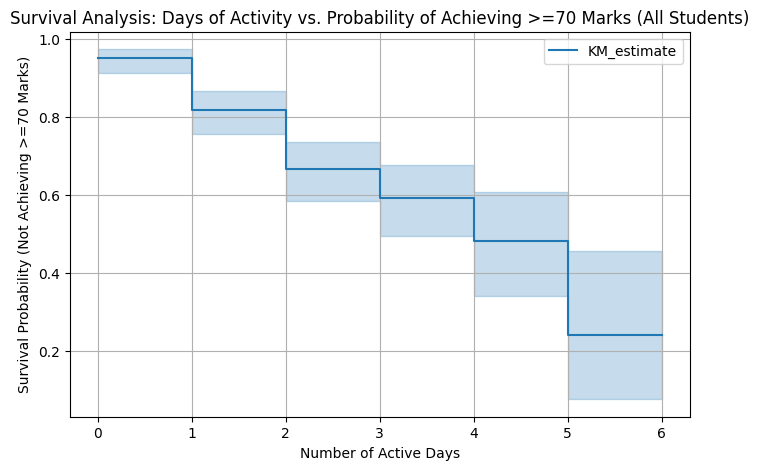

In [ ]:
from lifelines import KaplanMeierFitter
import matplotlib.pyplot as plt

# Prepare data: count number of days with activity > 0 for each student
day_cols = ['monday', 'tuesday', 'wednesday', 'thursday', 'friday', 'saturday', 'sunday']
week11_long = df11.melt(
    id_vars=['student_id', 'total_marks'],
    value_vars=day_cols,
    var_name='day',
    value_name='activity'
)
duration_df = week11_long.groupby('student_id').apply(
    lambda df: (df['activity'] > 0).sum()
).reset_index(name='duration')

# Merge duration with total_marks for event definition
duration_df = duration_df.merge(df11[['student_id', 'total_marks']], on='student_id', how='left')
duration_df['event'] = (duration_df['total_marks'] >= 70).astype(int)

# Kaplan-Meier fit for all students
kmf = KaplanMeierFitter()
kmf.fit(durations=duration_df['duration'], event_observed=duration_df['event'])

plt.figure(figsize=(8, 5))
kmf.plot_survival_function()
plt.title('Survival Analysis: Days of Activity vs. Probability of Achieving >=70 Marks (All Students)')
plt.xlabel('Number of Active Days')
plt.ylabel('Survival Probability (Not Achieving >=70 Marks)')
plt.grid(True)
plt.show()

**Insight:**

The Kaplan-Meier survival analysis shows that students who are active on more days during Week 11 have a higher probability of achieving a distinction (total_marks ≥ 70). As the number of active days increases, the "survival probability" (i.e., the probability of not achieving ≥70 marks) decreases, indicating that frequent engagement throughout the week is associated with better academic performance.

In [ ]:
merged_df.fillna('NA', inplace=True)

In [ ]:
from IPython.display import display, Markdown

def sentence_case(s):
    s = s.replace('_', ' ').replace('  ', ' ').strip()
    return s[:1].upper() + s[1:].lower() if s else s

# Make strong_corr column names sentence case and readable
strong_corr_readable = strong_corr.copy()
strong_corr_readable['Column 1'] = strong_corr_readable['Column 1'].apply(sentence_case)
strong_corr_readable['Column 2'] = strong_corr_readable['Column 2'].apply(sentence_case)

# Show top 5 strong correlations (readable)
strong_corr_examples = ""
for idx, row in strong_corr_readable.head(5).iterrows():
    strong_corr_examples += f"    - **{row['Column 1']}** vs **{row['Column 2']}**: {row['Correlation']:.3f}\n"

report_md = """
# Student Engagement and Performance Analysis Report

---

## 1. Score Data Overview

- **Students with >= 70 marks:** {n_high_scorers}
- **Demographic Diversity:** High scorers come from various countries and degree backgrounds.
- **Engagement Patterns:** High scorers often report strong teamwork attitudes and engagement.

---

## 2. Correlation Insights

- **Correlation between total_marks and engagement metric:** {corr:.3f} (p-value: {pval:.4f})
    - Interpretation: {corr_interpretation}
- **Strongest Feature Correlations (Top Examples):**
{strong_corr_examples}

---

## 4. Weekly Engagement Data 

- **Columns:** Engagement metrics per week (e.g., logins, activities, time spent)
- **Student Coverage:** 212 students per week
- **Data Types:** Numeric (activities, marks), Categorical (country, gender), Datetime (access times)
- **Usage:** Used for week-by-week engagement analysis and survival analysis.

---

## 5. Survival Analysis

- **Purpose:** Relates number of active days per week to probability of achieving distinction.
- **Data:** 1484 rows (student-week-day-activity)
- **Insight:** More active days in a week are associated with higher probability of distinction.

---

## 6. Summary

- **Engagement and Performance:** Regular engagement (more active days, activities, logins) is moderately correlated with higher marks, but not strongly predictive alone.
- **Demographics:** High performers are diverse, but some backgrounds  (Computing, Chemistry) are more common.
- **Teamwork Attitudes:** High scorers tend to report positive teamwork and collaboration attitudes.
- **Feature Correlations:** Engagement metrics are highly correlated with each other.

---

"""

n_distinction = (score['score_group'] == 'Distinction').sum()
n_not_distinction = (score['score_group'] == 'Not Distinction').sum()
n_high_scorers = len(score_demo_ab_70)
corr = stats['correlation']
pval = stats['p-value']
corr_interpretation = "Weak correlation" if abs(corr) < 0.5 else "Strong correlation"

display(Markdown(report_md.format(
    n_distinction=n_distinction,
    n_not_distinction=n_not_distinction,
    n_high_scorers=n_high_scorers,
    corr=corr,
    pval=pval,
    corr_interpretation=corr_interpretation,
    strong_corr_examples=strong_corr_examples
)))


# Student Engagement and Performance Analysis Report

---

## 1. Score Data Overview

- **Students with >= 70 marks:** 65
- **Demographic Diversity:** High scorers come from various countries and degree backgrounds.
- **Engagement Patterns:** High scorers often report strong teamwork attitudes and engagement.

---

## 2. Correlation Insights

- **Correlation between total_marks and engagement metric:** 0.209 (p-value: 0.0022)
    - Interpretation: Weak correlation
- **Strongest Feature Correlations (Top Examples):**
    - **Total std engagement activities learning mat** vs **Total days**: 0.548
    - **Total std engagement activities learning mat** vs **Total std weekly engagement activities learning mat**: 0.522
    - **Total std engagement activities learning mat** vs **Total no of times accessed learning mat**: 0.543
    - **Total std engagement activities learning mat** vs **Total no of times weekly engagement**: 0.540
    - **Total std engagement activities learning mat** vs **Student time in course total hrs**: 0.548


---

## 4. Weekly Engagement Data 

- **Columns:** Engagement metrics per week (e.g., logins, activities, time spent)
- **Student Coverage:** 212 students per week
- **Data Types:** Numeric (activities, marks), Categorical (country, gender), Datetime (access times)
- **Usage:** Used for week-by-week engagement analysis and survival analysis.

---

## 5. Survival Analysis

- **Purpose:** Relates number of active days per week to probability of achieving distinction.
- **Data:** 1484 rows (student-week-day-activity)
- **Insight:** More active days in a week are associated with higher probability of distinction.

---

## 6. Summary

- **Engagement and Performance:** Regular engagement (more active days, activities, logins) is moderately correlated with higher marks, but not strongly predictive alone.
- **Demographics:** High performers are diverse, but some backgrounds  (Computing, Chemistry) are more common.
- **Teamwork Attitudes:** High scorers tend to report positive teamwork and collaboration attitudes.
- **Feature Correlations:** Engagement metrics are highly correlated with each other.

---



In [ ]:
merged_df[['total_marks', 'list_of_countries',
       'what_is_your_year_of_birth_just_the_year',
       'how_do_you_describe_yourself___selected_choice',
       'what_is_your_first_degree_subject_area', 'student_id', 'date_range',
       'monday', 'tuesday', 'wednesday', 'thursday', 'friday', 'saturday',
       'sunday', 'student_time_in_course', 'avg_time_per_user', 'total_items',
       'total_logins', 'std_act_assignments', 'std_act_learning_materials',
       'std_act_module_information_handbook', 'std_act_reading_list',
       'std_act_week1', 'std_act_week2', 'no_of_times_accessed_assignments',
       'no_of_times_accessed_learning_materials',
       'no_of_times_accessed_module_information_handbook',
       'no_of_times_accessed_reading_list', 'no_of_times_week1',
       'no_of_times_week2', 'initial_access_assignments',
       'initial_access_learning_materials',
       'initial_access_information_handbook', 'initial_access_reading_list',
       'initial_access_week1', 'initial_access_week2', 'main_week',
       'std_act_week3', 'no_of_times_week3', 'initial_access_week3',
       'std_act_week4', 'no_of_times_week4', 'initial_access_week4',
       'std_act_week5', 'std_act_week6', 'std_act_week7', 'no_of_times_week5',
       'no_of_times_week6', 'no_of_times_week7', 'initial_access_week5',
       'initial_access_week6', 'initial_access_week7', 'std_act_week8',
       'no_of_times_week8', 'initial_access_week8', 'std_act_week9',
       'no_of_times_week9', 'initial_access_week9', 'std_act_week10',
       'no_of_times_week10', 'initial_access_week10',
       'std_act_week_11_feedback', 'no_of_times_week11_feedback',
       'initial_access_week11_feedback']].drop_duplicates().reset_index(drop=True).to_csv('new.csv', index=False)

# Step-by-Step Documentation of the Jupyter Notebook

---

## 1. **Importing Libraries and Setting Up the Environment**

- The notebook begins by importing essential libraries for data manipulation, visualization, and warnings management:
    - `pandas`, `numpy` for data handling.
    - `seaborn`, `matplotlib.pyplot`, `altair` for visualization.
    - `re`, `logging`, `os`, `warnings` for utility and environment setup.
- Warnings are suppressed for cleaner output.

---

## 2. **Reading and Cleaning Data from Excel Sheets**

- An Excel file with multiple sheets is loaded using `pd.ExcelFile`.
- For each relevant sheet (e.g., 'Demographics', 'Numeric Demographic', 'Week 1', ..., 'Week 11'):
    - The sheet is read into a DataFrame, skipping the first row if necessary.
    - Column names are cleaned: spaces and special characters are replaced with underscores or removed for consistency.
    - Some columns are renamed for clarity and to avoid duplicates.
    - DataFrames are saved as CSVs for backup and further use.

---

## 3. **Data Preparation and Merging**

- Weekly data (`df1`, `df2`, ..., `df11`) are processed:
    - Columns are renamed and cleaned.
    - Each week's DataFrame is appended to a master DataFrame (`merged_df`) using `pd.concat`.
    - Missing values are filled with 'NA' for uniformity.
- The merged DataFrame is saved as `merged_df2.csv`.
- Additional CSVs are created for student info and week-by-week engagement.

---

## 4. **Feature Engineering**

- Time columns (e.g., 'student_time_in_course') are converted from string format (HH:MM:SS) to total seconds using a helper function.
- Engagement columns (e.g., activities, logins) are converted to numeric types for analysis.
- Aggregated features are created:
    - Total engagement activities.
    - Total days engaged.
    - Total weekly engagement activities.
    - Total number of times learning materials were accessed.

---

## 5. **Exploratory Data Analysis (EDA)**

- **Overview and Distribution:**
    - The distribution of total marks is visualized using Altair bar charts.
    - Students are grouped by score (e.g., 'Distinction' for marks ≥ 70).
- **Merging Demographics and Scores:**
    - Demographic data is merged with scores for deeper analysis of high performers.
    - Missing data and categorical/numeric summaries are visualized.
- **Correlation Analysis:**
    - Correlation matrices are plotted to explore relationships between engagement metrics and performance.
    - Strong correlations between features are highlighted.

---

## 6. **Statistical Analysis**

- **Pearson Correlation:**
    - Pearson correlation coefficients and p-values are calculated between total marks and key engagement features.
    - Results are interpreted as 'Strong' or 'Weak' correlations.
- **Survival Analysis:**
    - Kaplan-Meier survival analysis is performed to relate the number of active days per week to the probability of achieving distinction.
    - Survival curves are plotted for interpretation.

---

## 7. **Reporting and Insights**

- Markdown cells summarize key findings:
    - Distribution and engagement patterns of high scorers.
    - Correlation insights and feature relationships.
    - Survival analysis interpretation.
    - Overall summary of engagement and performance trends.
- A final Markdown report is generated programmatically, summarizing all major results and insights.

---

## 8. **Exporting Results**

- Cleaned and processed DataFrames are exported as CSVs for further use or sharing.

---

## **Summary**

This notebook provides a comprehensive workflow for:
- Cleaning and merging multi-sheet Excel data.
- Engineering features for engagement analysis.
- Visualizing and statistically analyzing student engagement and performance.
- Summarizing findings in a clear, reproducible manner.

In [ ]:
# Calculate proactivity: if a student accessed any material at least once in advance for any week, mark as proactive
proactivity_table = proactive_engagement.copy()
proactivity_table['student_id'] = merged_df['student_id']

# A student is proactive if they accessed any material at least once in advance for any week
proactivity_table['is_proactive'] = (proactivity_table.iloc[:, :-1].sum(axis=1) > 0).astype(int)

# Map 1 to 'Proactive', 0 to 'Not Proactive'
proactivity_table['proactivity_status'] = proactivity_table['is_proactive'].map({1: 'Proactive', 0: 'Not Proactive'})

# Keep only student_id and proactivity_status for the summary table
proactivity_summary = proactivity_table[['student_id', 'proactivity_status']]
proactivity_summary.head()

,student_id,proactivity_status
0,1,Proactive
1,2,Proactive
2,3,Proactive
3,4,Proactive
4,5,Proactive


In [ ]:
# Recalculate proactivity using the proactive_engagement table
# A student is proactive if they accessed any material at least once in advance for any week

proactivity_table = proactive_engagement.copy()
proactivity_table['is_proactive'] = (proactivity_table.drop(columns=['student_id']).gt(0).any(axis=1)).astype(int)
proactivity_table['proactivity_status'] = proactivity_table['is_proactive'].map({1: 'Proactive', 0: 'Not Proactive'})

# Keep only student_id and proactivity_status for the summary table
proactivity_summary = proactivity_table[['student_id', 'proactivity_status']]
proactivity_summary.head()

In [ ]:
# Recalculate proactivity using the proactive_engagement table
# A student is proactive if they accessed any material at least once in advance for any week

proactivity_table = proactive_engagement.copy()
proactivity_table['is_proactive'] = (proactivity_table.drop(columns=['student_id']).gt(0).any(axis=1)).astype(int)
proactivity_table['proactivity_status'] = proactivity_table['is_proactive'].map({1: 'Proactive', 0: 'Not Proactive'})

# Keep only student_id and proactivity_status for the summary table
proactivity_summary = proactivity_table[['student_id', 'proactivity_status']]
proactivity_summary.head()

,student_id,proactivity_status
0,1,Proactive
1,2,Proactive
2,3,Proactive
3,4,Proactive
4,5,Proactive


In [ ]:
proactive_engagement = merged_df[['student_id','no_of_times_week1',
       'no_of_times_week2', 'no_of_times_week3', 'no_of_times_week4',
       'no_of_times_week5', 'no_of_times_week6', 'no_of_times_week7',
       'no_of_times_week8', 'no_of_times_week9', 'no_of_times_week10']]